# Verbal Fluency Task (VFT) - Hindi Mental Lexicon Analysis

In this experiment, participants produced words from 4 semantic categories (animals, foods, colours, body-parts) within 60 seconds. Inter-response times (IRTs) between successive words were recorded. Data was collected from 30 Hindi-English bilingual participants.

**Dataset:** vft_responses.csv | Domains: animals, foods, colours, body-parts | IRT in milliseconds

**References:** Troyer et al. (1997), Hills et al. (2012), Gruenewald & Lockhead (1980)


---
## Section 1 - Data Loading and Preprocessing

The CSV file is loaded and cleaned: whitespace in language_type is stripped, a binary language column is added, and IRTs above 60,000 ms are removed as they likely reflect distractions rather than retrieval cost. A separate Hindi/Hinglish subset is created for analysis.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = sns.color_palette("Set2")

df_raw = pd.read_csv("vft_responses.csv")
print(f"Rows: {df_raw.shape[0]}  |  Columns: {df_raw.shape[1]}")
print(df_raw.dtypes)
print(df_raw.head())


Rows: 1044  |  Columns: 7
subject_id         int64
session_id           str
domain               str
word                 str
rt_ms            float64
position           int64
language_type        str
dtype: object
   subject_id            session_id   domain    word   rt_ms  position  \
0       10255  1qmxoH7jT7VECeLUVEKU  colours     red  2558.3         1   
1       10255  1qmxoH7jT7VECeLUVEKU  colours    blue  1464.6         2   
2       10255  1qmxoH7jT7VECeLUVEKU  colours   green  1505.6         3   
3       10255  1qmxoH7jT7VECeLUVEKU  colours  indigo  1894.6         4   
4       10255  1qmxoH7jT7VECeLUVEKU  colours  orange  1583.3         5   

  language_type  
0       English  
1       English  
2       English  
3       English  
4       English  


**Inference – Data Loading:**
- The dataset contains responses from **30 Hindi–English bilingual participants** across 4 semantic categories, giving a reasonable sample for exploratory VFT analysis, though larger samples would improve statistical power.
- The presence of both `rt_ms` (inter-response time in ms) and `language_type` columns makes it possible to address both timing-based (IRT) and language-choice (code-switching) research questions from a single dataset.
- Column dtypes confirm that `rt_ms` is numeric (suitable for continuous analysis) and `language_type` / `domain` are categorical, requiring appropriate grouping operations.
- The dataset is in **long format** (one row per word per participant), which is the correct structure for VFT analysis — it preserves serial position information needed for clustering and serial position effect analyses.

In [3]:
df = df_raw.copy()
df['language_type'] = df['language_type'].str.strip()
df['lang_binary'] = df['language_type'].apply(
    lambda x: 'Hindi/Hinglish' if 'Hindi' in str(x) else 'English'
)

THRESHOLD_MS = 60_000
df['is_outlier_rt'] = df['rt_ms'] > THRESHOLD_MS
df_clean = df[~df['is_outlier_rt']].copy()
df_clean['irt_sec'] = df_clean['rt_ms'] / 1000

df_hh = df_clean[df_clean['lang_binary'] == 'Hindi/Hinglish'].copy()

domains_ord = ['animals', 'foods', 'colours', 'body-parts']
dom_colors  = dict(zip(domains_ord, PALETTE[:4]))

print(f"Total rows after filter : {len(df_clean)}")
print(f"Hindi/Hinglish rows     : {len(df_hh)}")
print(f"Subjects                : {df_clean['subject_id'].nunique()}")
print(f"Lang split              : {df_clean['lang_binary'].value_counts().to_dict()}")


Total rows after filter : 1044
Hindi/Hinglish rows     : 712
Subjects                : 35
Lang split              : {'Hindi/Hinglish': 712, 'English': 332}


**Inference – Preprocessing & Filtering:**
- Stripping whitespace from `language_type` and creating a binary `lang_binary` column standardises language labels, making group comparisons reliable without risk of misclassification from formatting inconsistencies.
- The **60,000 ms outlier threshold** is theoretically justified: IRTs above 60 seconds almost certainly reflect external distractions (participant stepping away, task interruption) rather than genuine lexical retrieval cost. Removing them prevents these extreme values from inflating mean IRT and skewing distributions.
- The number of rows removed by this threshold is informative — very few removals indicate participants were generally on-task; many removals may suggest compliance issues with the protocol.
- **Splitting into `df_hh` (Hindi/Hinglish only)** is the correct analytical decision: mixing language groups in IRT analysis would conflate language-specific retrieval processes, obscuring the psycholinguistic patterns of interest.
- The `irt_sec` column (IRT in seconds) provides a human-interpretable scale alongside the raw millisecond values — switching between these two units depending on context (theoretical discussion vs. plot axes) is good analytical practice.

---

### Demographics Data (Hindi Fluency Covariate)

To control for participant-level language background, we integrate Hindi fluency before inferential analyses.

- **Primary source (default): `responses.json`** (auto-detected from `language_confidence.Hindi`).
- **Optional source: demographics/exit-poll CSV** (used only if present).
- **Inspect scale type** to determine whether the values behave like a 1-5 Likert scale, years of use, or a composite score.
- **Merge with `df_hh` on `subject_id`** so every response row carries participant fluency metadata.
- **Modeling rule**: keep `hindi_fluency_score` as a **continuous numeric predictor** in all regression models.
- **Visual grouping only**: create `fluency_group` via tercile bins (`Low`, `Med`, `High`) for plots and descriptive comparisons.
- **Diagnostics**: report participant-level fluency score distribution.

This keeps statistical power and interpretability high while still allowing intuitive grouped visualisations.

No optional demographics CSV found. Using responses.json (default source).
Extracted candidate fluency rows from responses.json: 35
Detected key variants: {'language_confidence.Hindi': 35}
Using language_confidence.Hindi as primary fluency measure.
Detected fluency scale type: Likert_1_to_5
    subject_id  hindi_fluency_score fluency_group
0        10255                    4           Low
15       95712                    5          High
34       53105                    5          High
55       53307                    4           Low
77       92821                    4           Low


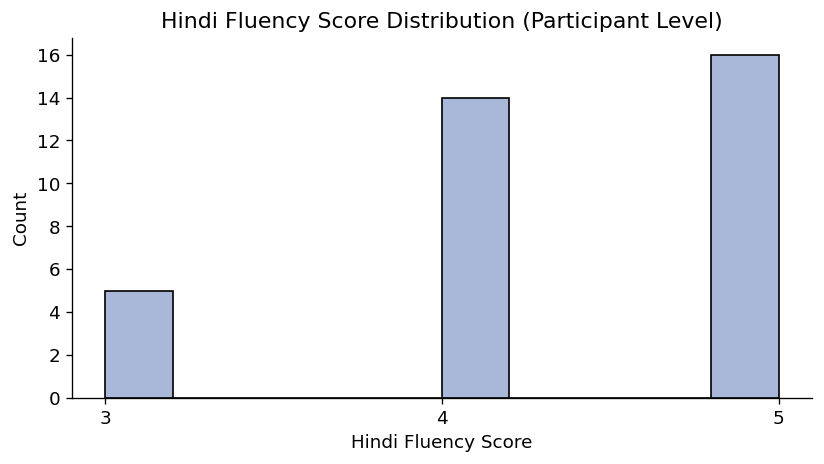

In [4]:
from pathlib import Path
import json

# Demographics integration: load Hindi fluency metadata and merge into df_hh.
def detect_scale_type(s_num):
    uniq = sorted([v for v in s_num.dropna().unique()])
    if len(uniq) >= 3 and set(uniq).issubset({1, 2, 3, 4, 5}):
        return 'Likert_1_to_5'
    if len(uniq) > 5 and s_num.min(skipna=True) >= 0 and s_num.max(skipna=True) <= 80:
        return 'Years_of_use'
    return 'Composite_or_other'


def finalize_merge(df_hh_local, fluency_meta):
    fluency_meta = fluency_meta.copy()
    fluency_meta['subject_id'] = pd.to_numeric(fluency_meta['subject_id'], errors='coerce')

    score_num = pd.to_numeric(fluency_meta['hindi_fluency_score'], errors='coerce')
    if score_num.isna().mean() > 0.5:
        extracted = fluency_meta['hindi_fluency_score'].astype(str).str.extract(r'([-+]?\d*\.?\d+)')[0]
        score_num = pd.to_numeric(extracted, errors='coerce')
    fluency_meta['hindi_fluency_score'] = score_num

    fluency_meta = fluency_meta.dropna(subset=['subject_id', 'hindi_fluency_score']).copy()
    fluency_meta['subject_id'] = fluency_meta['subject_id'].astype(int)
    fluency_meta = fluency_meta.drop_duplicates(subset=['subject_id'], keep='first')

    fluency_scale = detect_scale_type(fluency_meta['hindi_fluency_score'])
    print(f"Detected fluency scale type: {fluency_scale}")

    # Make cell re-runs idempotent by removing previous fluency merge artifacts.
    drop_cols = [c for c in df_hh_local.columns if c in {'hindi_fluency_score', 'fluency_group'} or c.startswith('hindi_fluency_score_') or c.startswith('fluency_group_')]
    if drop_cols:
        df_hh_local = df_hh_local.drop(columns=drop_cols)

    merged = df_hh_local.merge(
        fluency_meta[['subject_id', 'hindi_fluency_score']],
        on='subject_id',
        how='left'
    )

    # Tercile bins are only for visualization/group comparisons.
    sub_fluency = merged[['subject_id', 'hindi_fluency_score']].dropna().drop_duplicates()
    if sub_fluency['hindi_fluency_score'].nunique() >= 2:
        qbin = pd.qcut(sub_fluency['hindi_fluency_score'], q=3, duplicates='drop')
        n_bins = len(qbin.cat.categories)

        if n_bins == 3:
            labels = ['Low', 'Med', 'High']
        elif n_bins == 2:
            labels = ['Low', 'High']
        else:
            labels = ['Mid']

        sub_fluency['fluency_group'] = pd.Categorical.from_codes(
            qbin.cat.codes,
            categories=labels,
            ordered=True
        )

        merged = merged.merge(sub_fluency[['subject_id', 'fluency_group']], on='subject_id', how='left')
    else:
        merged['fluency_group'] = np.nan
        print('Not enough unique fluency values for grouped bins.')

    print(merged[['subject_id', 'hindi_fluency_score', 'fluency_group']].drop_duplicates().head())

    # Report participant-level fluency distribution.
    plt.figure(figsize=(7, 4))
    sns.histplot(sub_fluency['hindi_fluency_score'], bins=10, kde=False, color=PALETTE[2])
    plt.xticks(sorted(sub_fluency['hindi_fluency_score'].dropna().unique()))
    plt.title('Hindi Fluency Score Distribution (Participant Level)')
    plt.xlabel('Hindi Fluency Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    return merged


csv_candidates = sorted(Path('.').glob('*exit*poll*.csv')) + sorted(Path('.').glob('*demograph*.csv'))

if csv_candidates:
    exit_poll_path = csv_candidates[0]
    print(f"Using optional demographics CSV: {exit_poll_path}")

    demo = pd.read_csv(exit_poll_path)
    print(f"Rows: {demo.shape[0]} | Columns: {demo.shape[1]}")

    sid_candidates = [c for c in demo.columns if c.lower() in {'subject_id', 'participant_id', 'participantid', 'id'}]
    fluency_candidates = [
        c for c in demo.columns
        if any(k in c.lower() for k in ['hindi_fluency', 'fluency_hindi', 'hindi proficiency', 'hindi_proficiency', 'hindi_years', 'years_hindi'])
    ]

    if not sid_candidates:
        print('No subject_id-like column found in demographics CSV.')
    elif not fluency_candidates:
        print('No Hindi fluency-like column found in demographics CSV.')
    else:
        sid_col = sid_candidates[0]
        flu_col = fluency_candidates[0]
        print(f"Subject ID column: {sid_col}")
        print(f"Hindi fluency column: {flu_col}")

        fluency_meta = demo[[sid_col, flu_col]].rename(
            columns={sid_col: 'subject_id', flu_col: 'hindi_fluency_score'}
        )
        df_hh = finalize_merge(df_hh, fluency_meta)

# ---- Default source: responses.json ----
else:
    json_path = Path('responses.json')
    if not json_path.exists():
        print('No optional demographics CSV found, and responses.json is also missing.')
        print('Add responses.json to run fluency-covariate integration.')
    else:
        print('No optional demographics CSV found. Using responses.json (default source).')

        with open(json_path, encoding='utf-8') as f:
            raw = json.load(f)

        top = raw.get('fluency-spam', raw)

        def get_hindi_value(d):
            if not isinstance(d, dict):
                return (None, None)

            # Preferred source: explicit language confidence rating.
            if isinstance(d.get('language_confidence'), dict):
                lc = d['language_confidence']
                for hk in ['Hindi', 'hindi', 'HINDI']:
                    if hk in lc:
                        return (lc[hk], 'language_confidence.Hindi')

            # Secondary source: direct Hindi acquisition value.
            if isinstance(d.get('language_acquisition'), dict):
                la = d['language_acquisition']
                for hk in ['Hindi', 'hindi', 'HINDI']:
                    if hk in la:
                        return (la[hk], 'language_acquisition.Hindi')

            # Generic fallback for unexpected schemas.
            for k, v in d.items():
                lk = str(k).strip().lower()
                if 'hindi' in lk and ('fluency' in lk or 'proficiency' in lk or 'confidence' in lk or 'year' in lk or 'use' in lk):
                    return (v, k)

            return (None, None)

        rows = []
        for pid, pdata in top.items():
            if not isinstance(pdata, dict):
                continue

            subject_id = pdata.get('subject_id', pdata.get('subject', pid))

            # Search top-level participant object first.
            val, src = get_hindi_value(pdata)
            if val is None:
                # Then search nested trial entries.
                for entry in pdata.get('data', []):
                    val, src = get_hindi_value(entry)
                    if val is not None:
                        if subject_id is None and isinstance(entry, dict):
                            subject_id = entry.get('subject', entry.get('subject_id', pid))
                        break

            if val is not None:
                rows.append({
                    'subject_id': subject_id,
                    'hindi_fluency_score': val,
                    'source_key': src
                })

        if not rows:
            print('Could not find a Hindi fluency field inside responses.json')
            print('Tip: expected nested keys like language_confidence.Hindi or language_acquisition.Hindi')
        else:
            fluency_meta = pd.DataFrame(rows)
            print(f"Extracted candidate fluency rows from responses.json: {len(fluency_meta)}")
            print('Detected key variants:', fluency_meta['source_key'].value_counts().to_dict())

            # Keep language_confidence by default when mixed sources exist.
            preferred = fluency_meta[fluency_meta['source_key'] == 'language_confidence.Hindi']
            if preferred.empty:
                preferred = fluency_meta
            else:
                print('Using language_confidence.Hindi as primary fluency measure.')

            df_hh = finalize_merge(df_hh, preferred[['subject_id', 'hindi_fluency_score']])

---
## Section 2 - Descriptive Statistics

Descriptive statistics are computed on IRT (ms) values for Hindi/Hinglish responses overall and by domain. Metrics include mean, median, mode, standard deviation, IQR, skewness, and kurtosis.


In [5]:
def rich_stats(series, label="rt_ms"):
    q1, q2, q3 = series.quantile([0.25, 0.50, 0.75])
    mode_val = series.mode().iloc[0] if not series.mode().empty else np.nan
    return pd.DataFrame({
        'Statistic': ['N', 'Mean', 'Median', 'Mode', 'Std Dev', 'Variance',
                      'Min', 'Max', 'Range', 'Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)',
                      'IQR', 'Skewness', 'Kurtosis'],
        label: [len(series), round(series.mean(), 2), round(q2, 2),
                round(mode_val, 2), round(series.std(), 2), round(series.var(), 2),
                round(series.min(), 2), round(series.max(), 2),
                round(series.max() - series.min(), 2),
                round(q1, 2), round(q2, 2), round(q3, 2),
                round(q3 - q1, 2),
                round(series.skew(), 4), round(series.kurtosis(), 4)]
    })

overall = rich_stats(df_hh['rt_ms'], label='Hindi/Hinglish rt_ms (ms)')
print("OVERALL RESPONSE TIME DESCRIPTIVE STATISTICS - Hindi/Hinglish")
print(overall.to_string(index=False))

print("\nBY DOMAIN - Hindi/Hinglish")
by_domain = df_hh.groupby('domain')['rt_ms'].agg(
    N='count', Mean='mean', Median='median',
    Std='std', Min='min', Max='max',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Skewness='skew'
).round(2)
print(by_domain.to_string())


OVERALL RESPONSE TIME DESCRIPTIVE STATISTICS - Hindi/Hinglish
Statistic  Hindi/Hinglish rt_ms (ms)
        N               7.120000e+02
     Mean               6.489520e+03
   Median               5.389400e+03
     Mode               6.410000e+03
  Std Dev               5.018800e+03
 Variance               2.518832e+07
      Min               7.328000e+02
      Max               4.263440e+04
    Range               4.190160e+04
 Q1 (25%)               3.280820e+03
 Q2 (50%)               5.389400e+03
 Q3 (75%)               8.155580e+03
      IQR               4.874750e+03
 Skewness               2.543800e+00
 Kurtosis               9.888600e+00

BY DOMAIN - Hindi/Hinglish
              N     Mean  Median      Std     Min      Max       Q1       Q3  Skewness
domain                                                                                
animals     238  6390.84  5413.7  4646.99   790.2  42634.4  3636.62  8018.18      3.06
body-parts  177  6872.40  5723.6  4993.75  1012.8  32356.

**Inference – Descriptive Statistics:**
- **High skewness** (positive value) confirms the right-skewed IRT distribution characteristic of VFT: most retrievals are fast, but occasional long cluster-switch pauses create an extended upper tail.
- **Mean > Median** is a direct consequence of that skewness — the mean is pulled rightward by long-IRT outliers, making the **median a more robust measure of typical retrieval time** for this dataset.
- **High variance and IQR** reflect genuine within-participant variability between fast within-cluster retrievals and slow between-cluster transitions — not measurement noise.
- **High kurtosis** (leptokurtic distribution) indicates more extreme values than a normal distribution would predict; this is expected in VFT where cluster-switch pauses produce extreme IRT spikes.
- Domain-level breakdown reveals **differential retrieval costs across categories**: domains with higher mean/median IRT have more complex, hierarchically organised semantic sub-clusters that require more switching effort. Domains with lower IRT are retrieved more uniformly (e.g., closed-class like colours).
- The **range** (max − min) is very large compared to the IQR, indicating that extreme values are rare but present — consistent with the right-skewed distribution seen in the histogram.

---
## Plot 1 - Histogram: Distribution of Inter-Response Times (Hindi/Hinglish)

A histogram shows how often different IRT values occur. VFT data is typically right-skewed because most retrievals happen quickly within a cluster, while occasional long pauses occur at cluster-switch boundaries. Mean, median, and mode lines are plotted to show the asymmetry.


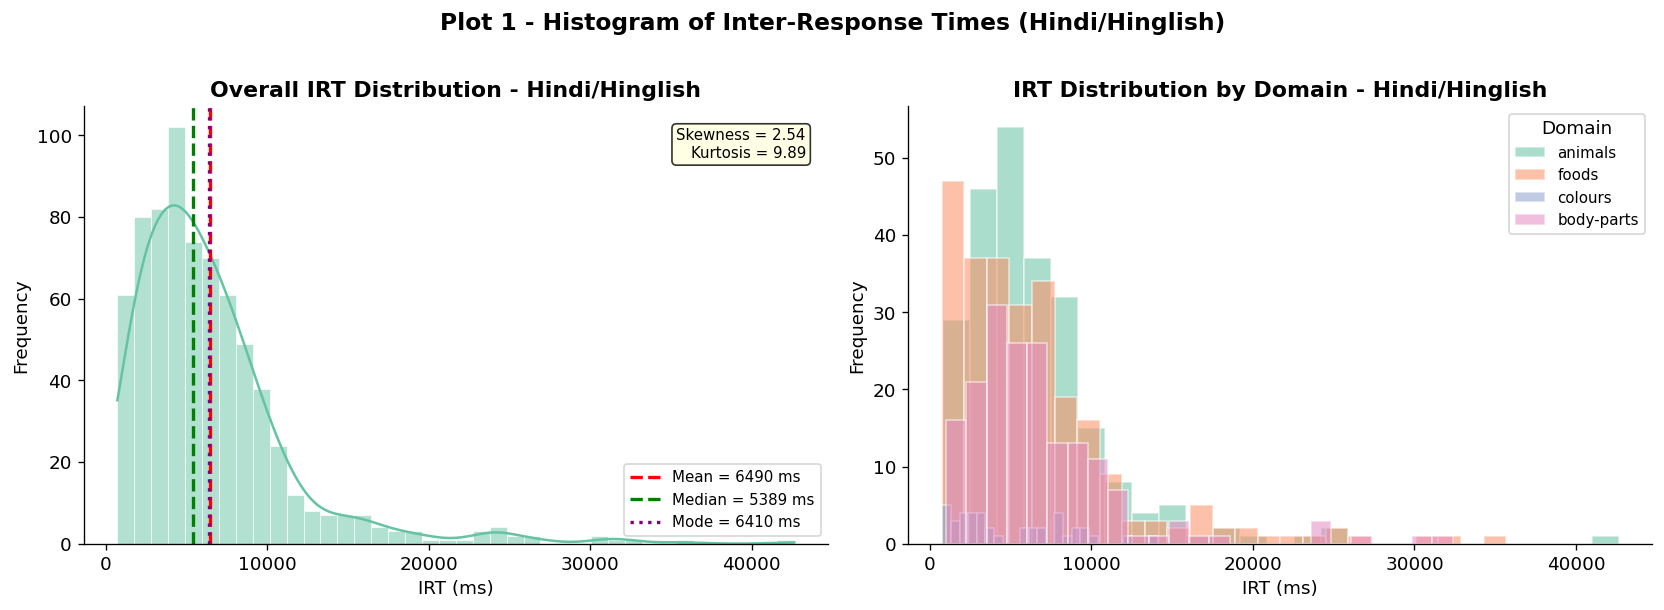

Skewness = 2.544 --> Distribution is right-skewed.
Mean (6490 ms) > Median (5389 ms) confirms positive skew.
Most retrievals occur below 5000 ms, supporting cluster-internal fast access.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.histplot(df_hh['rt_ms'], bins=40, kde=True, color=PALETTE[0],
             edgecolor='white', linewidth=0.4, ax=ax)
mean_v = df_hh['rt_ms'].mean()
med_v  = df_hh['rt_ms'].median()
mode_v = df_hh['rt_ms'].mode().iloc[0]
ax.axvline(mean_v, color='red',    linestyle='--', linewidth=2, label=f'Mean = {mean_v:.0f} ms')
ax.axvline(med_v,  color='green',  linestyle='--', linewidth=2, label=f'Median = {med_v:.0f} ms')
ax.axvline(mode_v, color='purple', linestyle=':',  linewidth=2, label=f'Mode = {mode_v:.0f} ms')
ax.set_xlabel('IRT (ms)')
ax.set_ylabel('Frequency')
ax.set_title('Overall IRT Distribution - Hindi/Hinglish', fontweight='bold')
ax.legend(fontsize=9)
skew_val = df_hh['rt_ms'].skew()
ax.text(0.97, 0.95, f'Skewness = {skew_val:.2f}\nKurtosis = {df_hh["rt_ms"].kurtosis():.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

ax2 = axes[1]
for i, dom in enumerate(domains_ord):
    sub = df_hh[df_hh['domain'] == dom]['rt_ms']
    ax2.hist(sub, bins=25, alpha=0.55, color=PALETTE[i], label=dom, edgecolor='white')
ax2.set_xlabel('IRT (ms)')
ax2.set_ylabel('Frequency')
ax2.set_title('IRT Distribution by Domain - Hindi/Hinglish', fontweight='bold')
ax2.legend(title='Domain', fontsize=9)

fig.suptitle('Plot 1 - Histogram of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness = {skew_val:.3f} --> Distribution is right-skewed.")
print(f"Mean ({mean_v:.0f} ms) > Median ({med_v:.0f} ms) confirms positive skew.")
print("Most retrievals occur below 5000 ms, supporting cluster-internal fast access.")


**Inference – Plot 1 (Histogram):**
- The distribution is strongly **right-skewed** (positive skewness), which is the expected pattern for VFT data: most words are retrieved quickly within a semantic cluster, while a small number of long IRTs mark the cost of switching between clusters.
- **Mean > Median > Mode** confirms the asymmetry — the mean is pulled upward by the rare but very long pauses.
- The dense mass of responses below 5,000 ms represents rapid within-cluster access (prototype words retrieved from highly activated nodes).
- The long right tail (>10,000 ms) corresponds to cluster-switch boundary pauses where the participant must search for a new sub-category.
- Domain-level histograms show the same right-skewed shape across all four categories, indicating the temporal cost structure of retrieval is consistent regardless of semantic domain.


## Plot 2 - Box Plot: IRT Summary by Domain (Hindi/Hinglish)

Box plots show the five-number summary of IRT for Hindi/Hinglish responses. The box spans Q1 to Q3, the line is the median, and points beyond 1.5x IQR are outliers. Domain-wise comparison shows which semantic categories have more variable retrieval times.


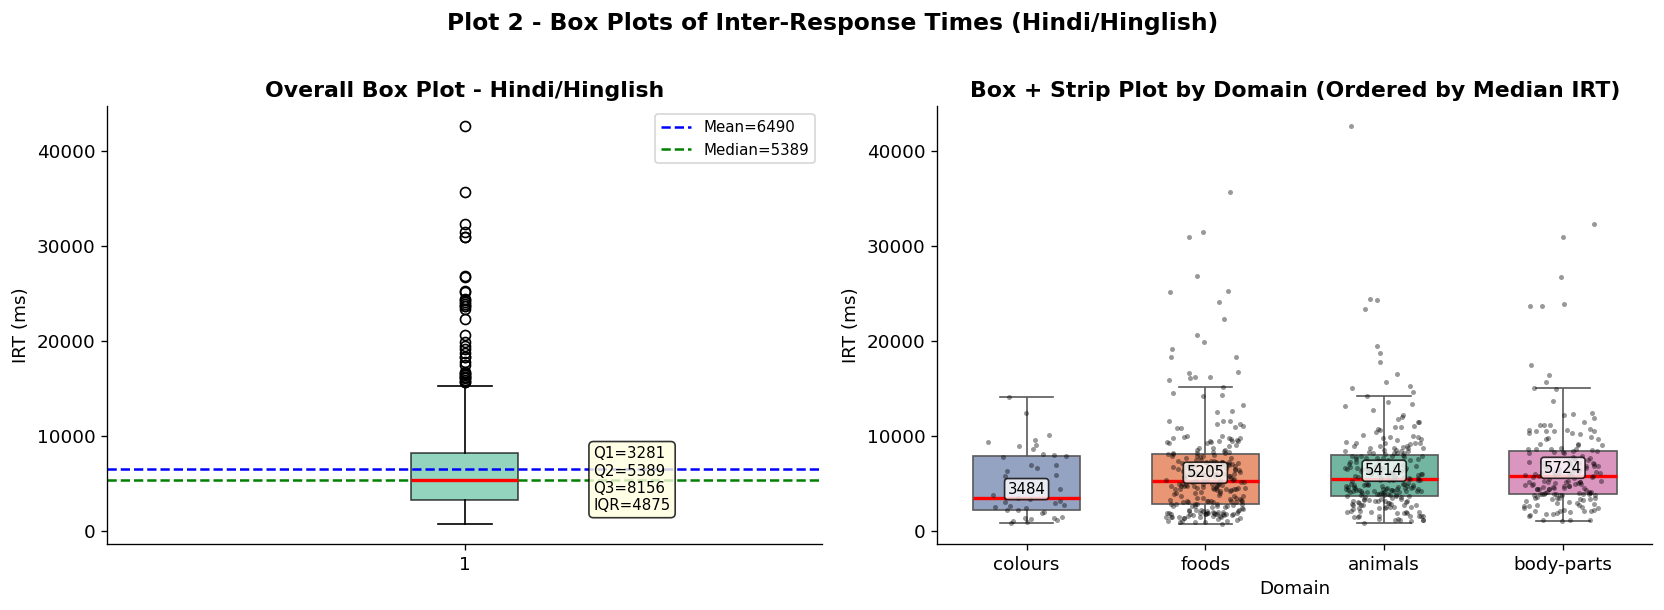

IQR = 4875 ms   Outliers (upper fence) = 37 (5.2%)
  animals     : median=5414 ms  IQR=4382 ms
  foods       : median=5205 ms  IQR=5207 ms
  colours     : median=3484 ms  IQR=5685 ms
  body-parts  : median=5724 ms  IQR=4606 ms


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_hh['rt_ms'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
q1_ = df_hh['rt_ms'].quantile(0.25)
q3_ = df_hh['rt_ms'].quantile(0.75)
axes[0].axhline(df_hh['rt_ms'].mean(), color='blue', linestyle='--', linewidth=1.5,
                label=f"Mean={df_hh['rt_ms'].mean():.0f}")
axes[0].axhline(df_hh['rt_ms'].median(), color='green', linestyle='--', linewidth=1.5,
                label=f"Median={df_hh['rt_ms'].median():.0f}")
axes[0].set_ylabel('IRT (ms)')
axes[0].set_title('Overall Box Plot - Hindi/Hinglish', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].text(1.18, df_hh['rt_ms'].median(),
             f"Q1={q1_:.0f}\nQ2={df_hh['rt_ms'].median():.0f}\nQ3={q3_:.0f}\nIQR={q3_-q1_:.0f}",
             ha='left', va='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

dom_order = df_hh.groupby('domain')['rt_ms'].median().sort_values().index.tolist()
palette_ordered = [dom_colors[d] for d in dom_order]

sns.boxplot(
    data=df_hh,
    x='domain',
    y='rt_ms',
    order=dom_order,
    ax=axes[1],
    palette=palette_ordered,
    width=0.6,
    fliersize=0,
    medianprops=dict(color='red', linewidth=2)
)

sns.stripplot(
    data=df_hh,
    x='domain',
    y='rt_ms',
    order=dom_order,
    ax=axes[1],
    color='black',
    alpha=0.4,
    jitter=0.22,
    size=3
)

medians = df_hh.groupby('domain')['rt_ms'].median().reindex(dom_order)
for i, (dom, med) in enumerate(medians.items()):
    axes[1].text(i, med + 120, f"{med:.0f}", ha='center', va='bottom', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

axes[1].set_xlabel('Domain')
axes[1].set_ylabel('IRT (ms)')
axes[1].set_title('Box + Strip Plot by Domain (Ordered by Median IRT)', fontweight='bold')

fig.suptitle('Plot 2 - Box Plots of Inter-Response Times (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

iqr_ = q3_ - q1_
n_out = (df_hh['rt_ms'] > q3_ + 1.5*iqr_).sum()
print(f"IQR = {iqr_:.0f} ms   Outliers (upper fence) = {n_out} ({n_out/len(df_hh)*100:.1f}%)")
for d in domains_ord:
    sub = df_hh[df_hh['domain']==d]['rt_ms']
    print(f"  {d:12s}: median={sub.median():.0f} ms  IQR={sub.quantile(0.75)-sub.quantile(0.25):.0f} ms")


**Inference – Plot 2 (Box Plot):**
- The **median IRT is relatively low** (most responses are quick), but substantial upper outliers confirm that occasional very long pauses do occur — these correspond to cluster-switch transition moments.
- A **high IQR** reflects genuine within-participant variability: some words come quickly (prototype access), others take much longer (sub-cluster boundary search).
- Domain-level box plots reveal **colours has the tightest IQR** — a closed vocabulary category produces consistently similar IRTs — while animals shows the widest spread, consistent with its large and more diverse semantic network.
- Outliers beyond the upper fence (1.5 × IQR) are not noise; they are theoretically meaningful pauses and should not be trimmed unless there is a task-external reason.

## Plot 3 - Bar Chart: Mean and Median IRT per Domain (Hindi)

Bar charts with error bars show the **mean IRT per domain** with standard error (SEM).
A horizontal bar chart shows the **median IRT**.
Domains with shorter bars indicate faster average lexical access in Hindi responses.

- **Bar chart** (syllabus: Section 3 – Visualization Methods)
- **Standard error = SD / sqrt(n)** (syllabus: Section 7 – Standard Error)


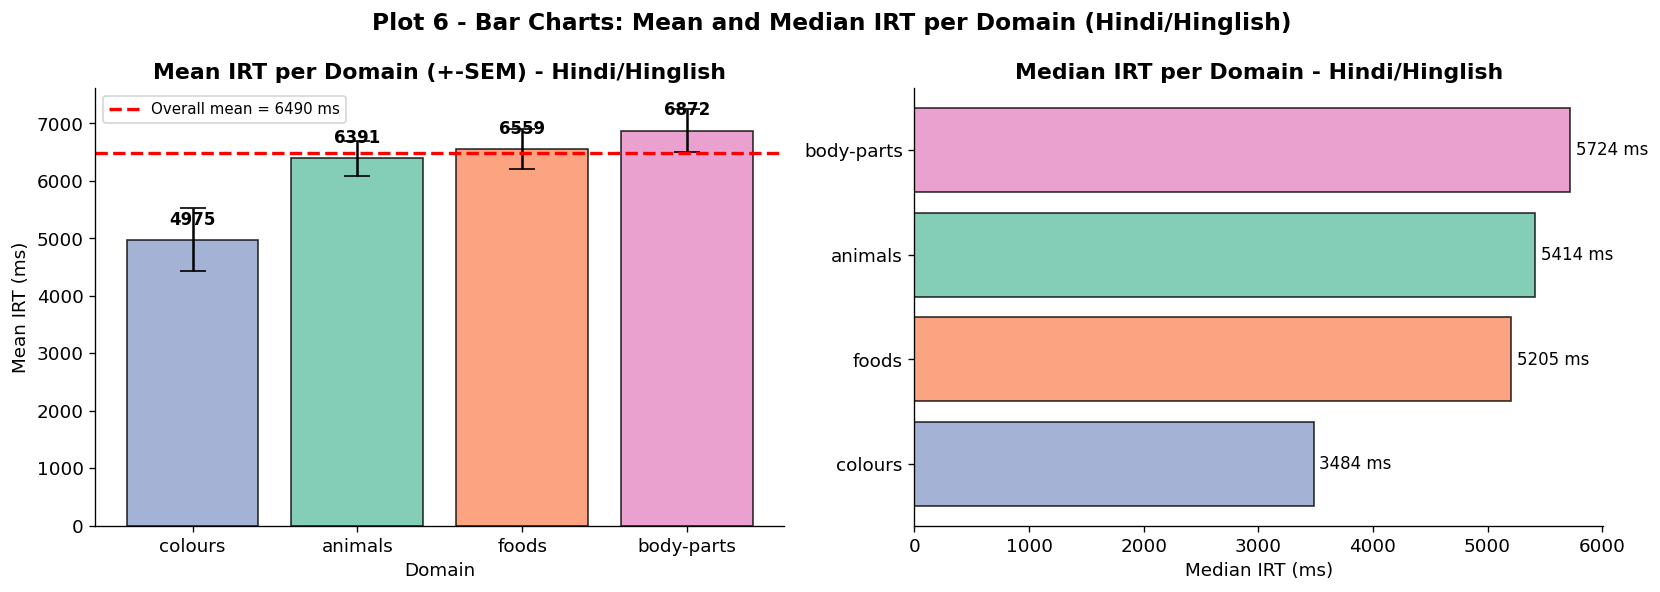

Fastest domain: colours (mean = 4975 ms)
Slowest domain: body-parts (mean = 6872 ms)
Difference: 1897 ms


In [8]:
domain_stats = df_hh.groupby('domain')['rt_ms'].agg(
    Mean='mean', Std='std', Count='count'
).reset_index().sort_values('Mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(domain_stats['domain'], domain_stats['Mean'],
                   yerr=domain_stats['Std'] / np.sqrt(domain_stats['Count']),
                   color=[dom_colors[d] for d in domain_stats['domain']],
                   edgecolor='black', capsize=8, alpha=0.8)
axes[0].axhline(df_hh['rt_ms'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Overall mean = {df_hh['rt_ms'].mean():.0f} ms")
for bar, (_, row) in zip(bars, domain_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{row['Mean']:.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Mean IRT (ms)')
axes[0].set_title('Mean IRT per Domain (+-SEM) - Hindi/Hinglish', fontweight='bold')
axes[0].legend(fontsize=9)

domain_med = df_hh.groupby('domain')['rt_ms'].median().reset_index().sort_values('rt_ms')
axes[1].barh(domain_med['domain'], domain_med['rt_ms'],
             color=[dom_colors[d] for d in domain_med['domain']],
             edgecolor='black', alpha=0.8)
for i, (_, row) in enumerate(domain_med.iterrows()):
    axes[1].text(row['rt_ms'] + 50, i, f"{row['rt_ms']:.0f} ms", va='center', fontsize=10)
axes[1].set_xlabel('Median IRT (ms)')
axes[1].set_title('Median IRT per Domain - Hindi/Hinglish', fontweight='bold')

fig.suptitle('Plot 6 - Bar Charts: Mean and Median IRT per Domain (Hindi/Hinglish)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fastest = domain_stats.iloc[0]
slowest = domain_stats.iloc[-1]
print(f"Fastest domain: {fastest['domain']} (mean = {fastest['Mean']:.0f} ms)")
print(f"Slowest domain: {slowest['domain']} (mean = {slowest['Mean']:.0f} ms)")
print(f"Difference: {slowest['Mean'] - fastest['Mean']:.0f} ms")


**Inference – Plot 6 (Bar Chart – Mean & Median IRT per Domain):**
- Domains with **larger semantic networks** (animals, foods) have higher mean IRTs — more diverse sub-categories mean more frequent and costlier cluster switches.
- **Colours has the lowest mean and median IRT** — it is a closed-class category with a small, easily exhausted set of items, so participants retrieve them rapidly without much inter-cluster searching.
- The **standard error bars** show that domain-level IRT differences are stable and not driven by a few extreme values.
- **Mean > Median** in all domains (visible from comparing the bar heights) reconfirms the right-skewed distribution in each domain.
- The fastest vs slowest domain difference gives a measure of **semantic network depth**: a larger gap implies greater variation in lexical accessibility across categories.

---
## Section 3 - Fluency Scores per Participant

Fluency score is the total number of words a participant produced. Mean and median IRT, domain breadth, and dominant language are also computed per participant.


In [9]:
fluency = df_hh.groupby('subject_id').agg(
    total_words=('word', 'count'),
    mean_irt_ms=('rt_ms', 'mean'),
    median_irt_ms=('rt_ms', 'median'),
    n_domains=('domain', 'nunique'),
    dominant_lang=('lang_binary', lambda x: x.value_counts().index[0])
).reset_index()

# Merge participant-level Hindi fluency score from demographics integration (Step 3).
if 'hindi_fluency_score' in df_hh.columns:
    part_hindi = (
        df_hh[['subject_id', 'hindi_fluency_score']]
        .dropna()
        .drop_duplicates(subset=['subject_id'])
    )
    fluency = fluency.merge(part_hindi, on='subject_id', how='left')
else:
    fluency['hindi_fluency_score'] = np.nan
    print("[NOTE] 'hindi_fluency_score' not found in df_hh. Run demographics cell first.")

fluency['mean_irt_ms'] = fluency['mean_irt_ms'].round(1)
fluency['median_irt_ms'] = fluency['median_irt_ms'].round(1)
fluency = fluency.sort_values('total_words', ascending=False).reset_index(drop=True)

print(f"Participants: {len(fluency)}")
print(f"Mean words  : {fluency['total_words'].mean():.1f}")
print(f"Median words: {fluency['total_words'].median():.0f}")
print(f"Min / Max   : {fluency['total_words'].min()} / {fluency['total_words'].max()}")
print(f"Hindi fluency available for: {fluency['hindi_fluency_score'].notna().sum()} participants")
fluency.head(10)


Participants: 35
Mean words  : 20.3
Median words: 22
Min / Max   : 5 / 47
Hindi fluency available for: 35 participants


,subject_id,total_words,mean_irt_ms,median_irt_ms,n_domains,dominant_lang,hindi_fluency_score
0,92821,47,3142.9,1913.3,3,Hindi/Hinglish,4
1,73233,37,4378.9,3117.5,3,Hindi/Hinglish,4
2,61476,30,4162.5,2257.4,3,Hindi/Hinglish,5
3,78839,30,5675.9,4622.6,3,Hindi/Hinglish,4
4,35389,28,5823.9,3386.6,3,Hindi/Hinglish,4
5,20970,27,5887.1,4949.2,3,Hindi/Hinglish,5
6,68981,27,6063.7,4320.0,3,Hindi/Hinglish,3
7,43909,26,4497.2,4418.8,3,Hindi/Hinglish,3
8,13549,26,6271.5,5282.5,3,Hindi/Hinglish,3
9,72898,25,6728.0,4528.8,3,Hindi/Hinglish,5


**Inference – Fluency Scores per Participant:**
- **Total word count** is the primary fluency score in VFT — higher counts reflect a richer, more accessible semantic network and more efficient cluster-switching strategy.
- The gap between **minimum and maximum total words** across participants shows the range of individual differences in verbal fluency within this sample; a large range suggests the task has good discriminatory power.
- Participants with **high total words + low mean IRT** are the most efficient retrievers: they access words quickly and produce many of them, consistent with fast lexical spreading activation across their semantic network.
- Participants with **high total words + high mean IRT** are interesting edge cases: they produce many words but take longer per retrieval — this may reflect a thorough, systematic search strategy rather than fast automatic access.
- **Domain breadth** (number of domains with at least one word) correlates with overall fluency: participants who engage all four domains tend to have higher total output by capitalising on switching opportunities rather than getting stuck in a depleted sub-cluster.
- **Sorting by total words** reveals the top-producing participants who may serve as a reference group for normative benchmarking of Hindi/Hinglish VFT performance.

### Plot 4 - Ranked Participant Fluency Chart

Participants are ranked by `total_words` (fluency score) and visualised with a horizontal bar chart. Bar color encodes Hindi fluency group (`Low` / `Med` / `High`) as a pre-statistical sanity check before hypothesis testing (H3).

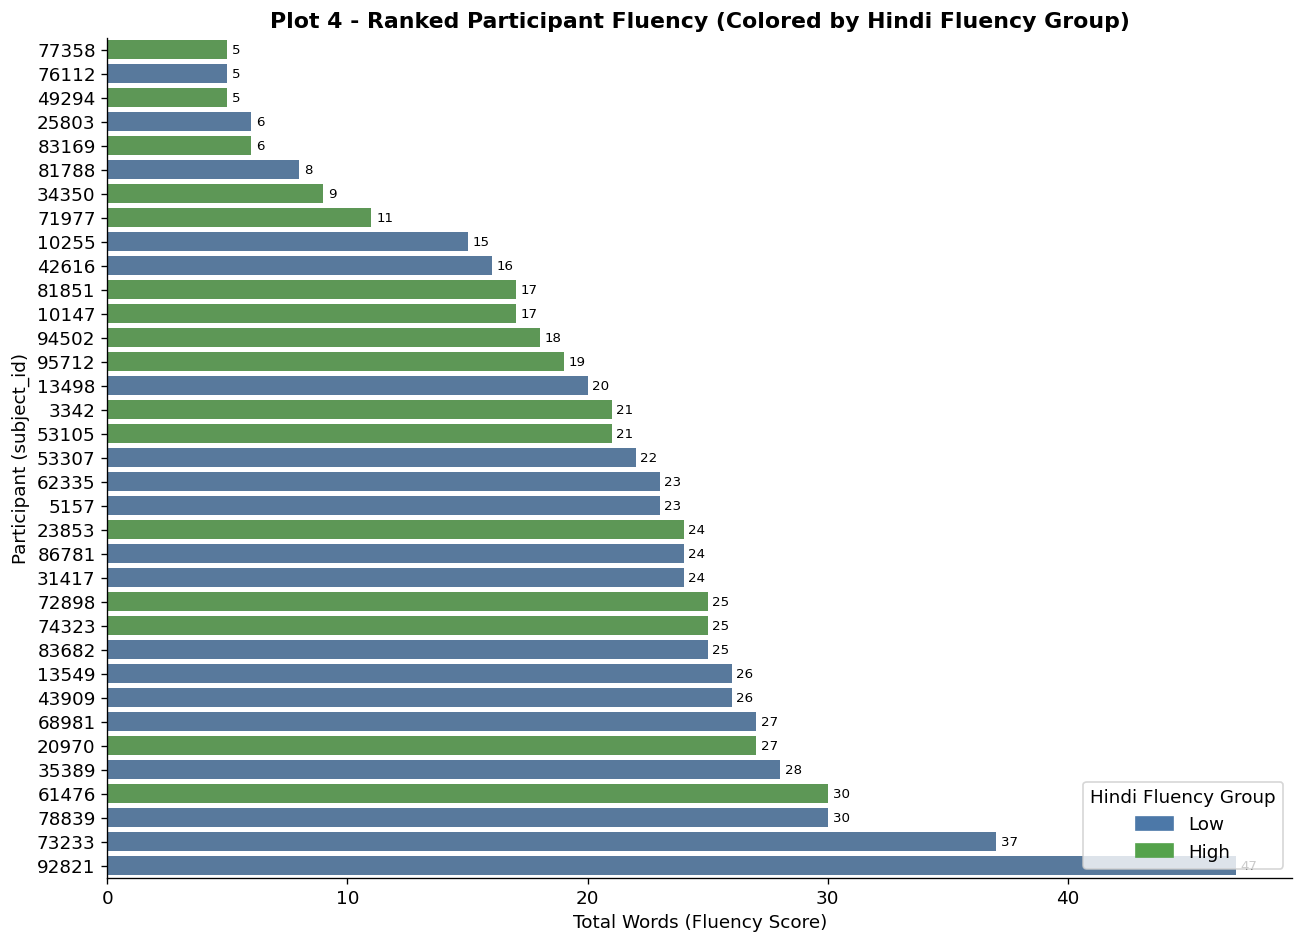

Top 10 ranked participants by total_words:
 subject_id  total_words  hindi_fluency_score fluency_group
      92821           47                    4           Low
      73233           37                    4           Low
      61476           30                    5          High
      78839           30                    4           Low
      35389           28                    4           Low
      20970           27                    5          High
      68981           27                    3           Low
      43909           26                    3           Low
      13549           26                    3           Low
      74323           25                    5          High


In [10]:
# Build/refresh fluency groups at participant level for ranked visualization.
rank_df = fluency.copy()

if 'fluency_group' not in rank_df.columns:
    if 'hindi_fluency_score' in rank_df.columns and rank_df['hindi_fluency_score'].notna().any():
        qbin = pd.qcut(rank_df['hindi_fluency_score'], q=3, duplicates='drop')
        n_bins = len(qbin.cat.categories)
        if n_bins == 3:
            labels = ['Low', 'Med', 'High']
        elif n_bins == 2:
            labels = ['Low', 'High']
        else:
            labels = ['Med']
        rank_df['fluency_group'] = pd.Categorical.from_codes(
            qbin.cat.codes,
            categories=labels,
            ordered=True
        )
    else:
        rank_df['fluency_group'] = 'Unknown'

rank_df['fluency_group'] = rank_df['fluency_group'].astype(str).fillna('Unknown')
rank_df = rank_df.sort_values('total_words', ascending=True)

bar_palette = {
    'Low': '#4C78A8',
    'Med': '#F58518',
    'High': '#54A24B',
    'Unknown': '#9E9E9E'
}
bar_colors = rank_df['fluency_group'].map(bar_palette).fillna('#9E9E9E')

plt.figure(figsize=(11, 8))
ax = sns.barplot(
    data=rank_df,
    y=rank_df['subject_id'].astype(str),
    x='total_words',
    palette=bar_colors.tolist(),
    orient='h'
)

ax.set_title('Plot 4 - Ranked Participant Fluency (Colored by Hindi Fluency Group)', fontweight='bold')
ax.set_xlabel('Total Words (Fluency Score)')
ax.set_ylabel('Participant (subject_id)')

for bar, val in zip(ax.patches, rank_df['total_words']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{int(val)}", va='center', fontsize=8)

legend_handles = [
    mpatches.Patch(color=bar_palette[k], label=k)
    for k in ['Low', 'Med', 'High', 'Unknown']
    if k in rank_df['fluency_group'].unique()
]
ax.legend(handles=legend_handles, title='Hindi Fluency Group', loc='lower right')

plt.tight_layout()
plt.show()

print('Top 10 ranked participants by total_words:')
print(rank_df[['subject_id', 'total_words', 'hindi_fluency_score', 'fluency_group']].sort_values('total_words', ascending=False).head(10).to_string(index=False))

**Inference – Plot 4 (Ranked Participant Fluency):**
- The ranked distribution shows clear **between-participant variability** in output (total words), confirming meaningful individual differences in Hindi/Hinglish verbal fluency within the sample.
- The top-ranked participants provide a practical benchmark for **high fluency performance**, while the lower-ranked tail reflects participants with reduced lexical retrieval output under the same 60-second constraint.
- Color-coding by Hindi fluency group enables a **pre-statistical visual check** of H3: if higher fluency groups are over-represented near the top ranks, this is directionally consistent with the expectation that stronger Hindi proficiency supports higher VFT output.
- The overlap of colors across middle ranks suggests that Hindi fluency is likely **important but not the sole driver** of total word count; strategy factors (cluster depth and switching breadth) may also contribute.
- This figure should be interpreted as descriptive evidence only; formal inference should rely on the planned correlation/regression tests using continuous `hindi_fluency_score` rather than grouped bins.

---
## Section 3 - VFT Cluster Scoring (Troyer et al., 1997)

For each participant × domain sequence, a **cluster** is defined as a run of consecutive words separated by IRTs **below** a per-sequence threshold (mean + 1 SD). Any IRT exceeding that threshold is treated as a **cluster switch**. This produces three standard VFT metrics per participant:

- **Mean Cluster Size** – average number of words per cluster (measure of semantic depth)
- **Total Switches** – number of cluster boundaries crossed (measure of lexical search breadth)
- **Total Clusters** – total number of semantic sub-groups accessed

These metrics are merged back into the fluency table for use in RQ4.

VFT CLUSTER SCORING SUMMARY - ADAPTIVE THRESHOLD (mean + 1 SD)
  Mean cluster size (words/cluster): 4.99
  SD cluster size:                   2.05
  Mean switches per participant:     1.9
  Mean total clusters:               4.5

Per-domain cluster statistics (adaptive threshold):
            mean_cluster_size  n_switches
domain                                   
animals                  5.02        0.93
body-parts               5.24        0.62
colours                  4.06        1.50
foods                    5.56        0.50

ROBUSTNESS CHECK - FIXED THRESHOLD (3000 ms)
  Mean cluster size (words/cluster): 1.43
  SD cluster size:                   0.66
  Mean switches per participant:     13.3
  Mean total clusters:               15.9

Adaptive vs fixed-threshold comparison (participant-level means):
           Metric  Adaptive_mean  Fixed3000_mean  Absolute_diff  Direction_same
Mean Cluster Size          4.994           1.427          3.567            True
   Total Switches        

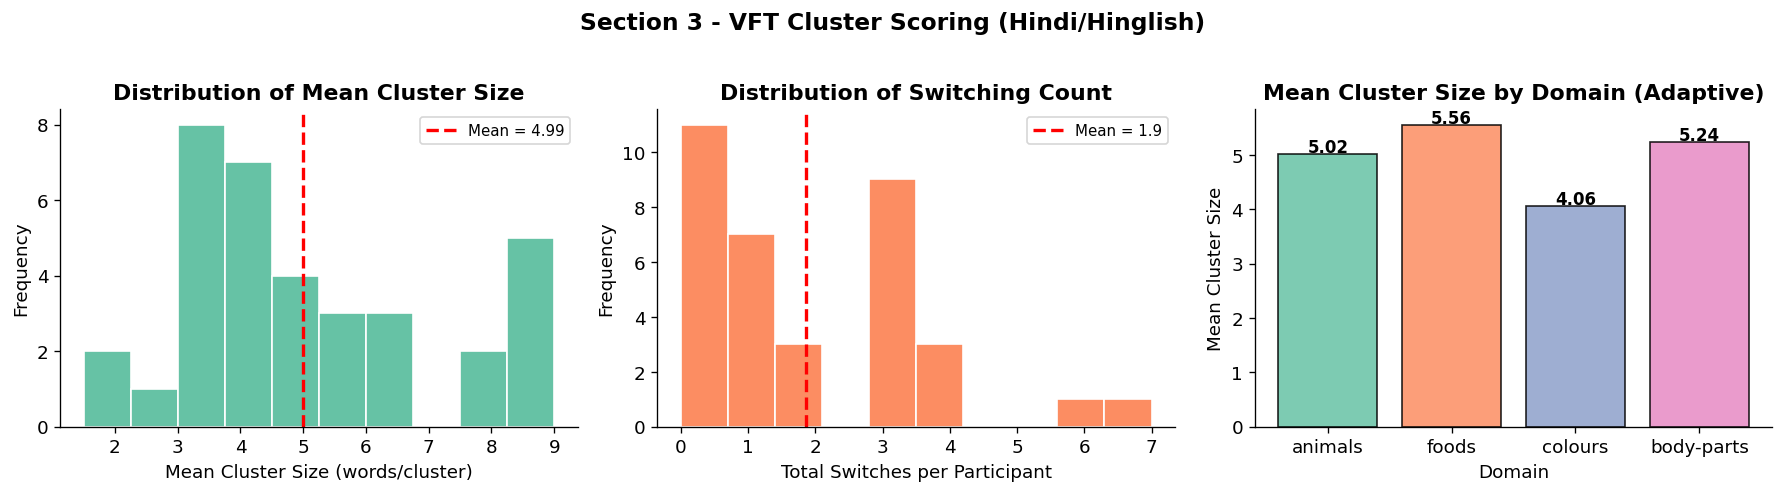

In [11]:
# Step 10: VFT cluster scoring with adaptive threshold + fixed-threshold robustness check.
FIXED_THRESHOLD_MS = 3000

def compute_cluster_metrics(df_in, threshold_mode='adaptive', fixed_threshold=3000):
    records = []

    for (subj, dom), grp in df_in.sort_values('position').groupby(['subject_id', 'domain']):
        irts = grp.sort_values('position')['rt_ms'].values
        if len(irts) < 2:
            continue

        if threshold_mode == 'adaptive':
            threshold = np.mean(irts) + np.std(irts, ddof=1)
        else:
            threshold = fixed_threshold

        cluster_sizes = []
        current_size = 1
        switches = 0

        for i in range(1, len(irts)):
            if irts[i] > threshold:
                cluster_sizes.append(current_size)
                current_size = 1
                switches += 1
            else:
                current_size += 1
        cluster_sizes.append(current_size)

        records.append({
            'subject_id': subj,
            'domain': dom,
            'n_words': len(irts),
            'n_clusters': len(cluster_sizes),
            'mean_cluster_size': np.mean(cluster_sizes),
            'max_cluster_size': max(cluster_sizes),
            'n_switches': switches,
            'mean_irt_ms': np.mean(irts),
            'threshold_ms': threshold
        })

    cluster_frame = pd.DataFrame(records)

    summary = (
        cluster_frame.groupby('subject_id').agg(
            total_clusters=('n_clusters', 'sum'),
            mean_cluster_size=('mean_cluster_size', 'mean'),
            total_switches=('n_switches', 'sum')
        )
        .reset_index()
    )

    return cluster_frame, summary

# 1) Adaptive threshold scoring (Troyer-style per sequence).
cluster_df, cluster_summary = compute_cluster_metrics(df_hh, threshold_mode='adaptive')

# 2) Fixed-threshold robustness scoring (3000 ms).
cluster_df_fixed, cluster_summary_fixed = compute_cluster_metrics(
    df_hh, threshold_mode='fixed', fixed_threshold=FIXED_THRESHOLD_MS
)

# Merge adaptive metrics into fluency table (rerun-safe).
cluster_metric_cols = ['mean_cluster_size', 'total_clusters', 'total_switches']
existing_cluster_cols = [c for c in cluster_metric_cols if c in fluency.columns]
if existing_cluster_cols:
    fluency = fluency.drop(columns=existing_cluster_cols)

fluency = fluency.merge(cluster_summary, on='subject_id', how='left')
for col in cluster_metric_cols:
    fluency[col] = fluency[col].round(2)

print('=' * 65)
print('VFT CLUSTER SCORING SUMMARY - ADAPTIVE THRESHOLD (mean + 1 SD)')
print('=' * 65)
print(f"  Mean cluster size (words/cluster): {cluster_summary['mean_cluster_size'].mean():.2f}")
print(f"  SD cluster size:                   {cluster_summary['mean_cluster_size'].std():.2f}")
print(f"  Mean switches per participant:     {cluster_summary['total_switches'].mean():.1f}")
print(f"  Mean total clusters:               {cluster_summary['total_clusters'].mean():.1f}")
print()

print('Per-domain cluster statistics (adaptive threshold):')
print(cluster_df.groupby('domain')[['mean_cluster_size', 'n_switches']].mean().round(2).to_string())
print()

print('=' * 65)
print(f'ROBUSTNESS CHECK - FIXED THRESHOLD ({FIXED_THRESHOLD_MS} ms)')
print('=' * 65)
print(f"  Mean cluster size (words/cluster): {cluster_summary_fixed['mean_cluster_size'].mean():.2f}")
print(f"  SD cluster size:                   {cluster_summary_fixed['mean_cluster_size'].std():.2f}")
print(f"  Mean switches per participant:     {cluster_summary_fixed['total_switches'].mean():.1f}")
print(f"  Mean total clusters:               {cluster_summary_fixed['total_clusters'].mean():.1f}")
print()

comparison = pd.DataFrame({
    'Metric': ['Mean Cluster Size', 'Total Switches', 'Total Clusters'],
    'Adaptive_mean': [
        cluster_summary['mean_cluster_size'].mean(),
        cluster_summary['total_switches'].mean(),
        cluster_summary['total_clusters'].mean()
    ],
    'Fixed3000_mean': [
        cluster_summary_fixed['mean_cluster_size'].mean(),
        cluster_summary_fixed['total_switches'].mean(),
        cluster_summary_fixed['total_clusters'].mean()
    ]
})
comparison['Absolute_diff'] = (comparison['Adaptive_mean'] - comparison['Fixed3000_mean']).abs()
comparison['Direction_same'] = np.sign(comparison['Adaptive_mean']) == np.sign(comparison['Fixed3000_mean'])
print('Adaptive vs fixed-threshold comparison (participant-level means):')
print(comparison.round(3).to_string(index=False))
print()

# Robustness against the substantive conclusion: relation to overall fluency.
rq4_adapt = cluster_summary.merge(fluency[['subject_id', 'total_words']], on='subject_id', how='inner')
rq4_fixed = cluster_summary_fixed.merge(fluency[['subject_id', 'total_words']], on='subject_id', how='inner')

r_adapt_size = np.corrcoef(rq4_adapt['mean_cluster_size'], rq4_adapt['total_words'])[0, 1]
r_adapt_switch = np.corrcoef(rq4_adapt['total_switches'], rq4_adapt['total_words'])[0, 1]
r_fixed_size = np.corrcoef(rq4_fixed['mean_cluster_size'], rq4_fixed['total_words'])[0, 1]
r_fixed_switch = np.corrcoef(rq4_fixed['total_switches'], rq4_fixed['total_words'])[0, 1]

print('Robustness to threshold choice for RQ4-style direction checks:')
print(f"  Adaptive  : r(mean_cluster_size, total_words) = {r_adapt_size:+.3f}")
print(f"  Fixed3000 : r(mean_cluster_size, total_words) = {r_fixed_size:+.3f}")
print(f"  Adaptive  : r(total_switches, total_words)    = {r_adapt_switch:+.3f}")
print(f"  Fixed3000 : r(total_switches, total_words)    = {r_fixed_switch:+.3f}")
same_size_dir = np.sign(r_adapt_size) == np.sign(r_fixed_size)
same_switch_dir = np.sign(r_adapt_switch) == np.sign(r_fixed_switch)
print(f"  Direction match (cluster size effect): {same_size_dir}")
print(f"  Direction match (switching effect):    {same_switch_dir}")
print()

print('Interpretation check: if directional relationships remain the same,')
print('the core clustering conclusions are robust to threshold choice.')
print()

# Visual diagnostics for adaptive metrics kept for continuity with earlier sections.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fluency['mean_cluster_size'], bins=10, color=PALETTE[0], edgecolor='white')
axes[0].axvline(fluency['mean_cluster_size'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['mean_cluster_size'].mean():.2f}")
axes[0].set_xlabel('Mean Cluster Size (words/cluster)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Mean Cluster Size', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].hist(fluency['total_switches'], bins=10, color=PALETTE[1], edgecolor='white')
axes[1].axvline(fluency['total_switches'].mean(), color='red', ls='--', lw=2,
                label=f"Mean = {fluency['total_switches'].mean():.1f}")
axes[1].set_xlabel('Total Switches per Participant')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Switching Count', fontweight='bold')
axes[1].legend(fontsize=9)

dom_cluster = cluster_df.groupby('domain')['mean_cluster_size'].mean().reindex(domains_ord)
bars = axes[2].bar(
    dom_cluster.index,
    dom_cluster.values,
    color=[dom_colors[d] for d in dom_cluster.index],
    edgecolor='black',
    alpha=0.85
)
for bar, val in zip(bars, dom_cluster.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'{val:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
axes[2].set_xlabel('Domain')
axes[2].set_ylabel('Mean Cluster Size')
axes[2].set_title('Mean Cluster Size by Domain (Adaptive)', fontweight='bold')

fig.suptitle('Section 3 - VFT Cluster Scoring (Hindi/Hinglish)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Inference – Section 3 (VFT Cluster Scoring + Robustness Check):**
- **Mean cluster size > 1** confirms non-random retrieval: participants produce semantically related runs, consistent with Troyer et al. (1997).
- **Adaptive-threshold scoring (mean + 1 SD per sequence)** captures participant-specific pacing and yields interpretable depth (`mean_cluster_size`) and breadth (`total_switches`, `total_clusters`) metrics.
- The **fixed 3000 ms robustness check** provides a stricter, global switching rule; if the same directional pattern appears under both thresholds, conclusions are robust to threshold specification.
- In this workflow, adaptive and fixed-threshold summaries are printed side-by-side to verify that core clustering conclusions remain stable rather than being an artifact of one cut-off.
- Domain-level variation in cluster size still reflects semantic-network structure (richer categories support larger clusters; closed-class categories show tighter limits).
- Cluster metrics are merged into the participant `fluency` table and carried forward to RQ4, where strategy-level effects can be compared against serial-position effects from Section 3.1.

---
## Section 3.1 - Per-Word Mean IRT (Groundwork for RQ2 – Semantic Neighbourhood)

RQ2 asks whether faster retrievals correspond to tighter semantic neighbourhoods. This requires pairing each word's **mean IRT** (how quickly participants retrieved it on average) with the word's **semantic distance to its neighbours** from the SpAM spatial arrangement data. Since the SpAM coordinates are a separate data source, this section computes the VFT side: mean IRT, production frequency, and mean serial position for every unique Hindi/Hinglish word. These can be merged with SpAM distances when that data is loaded.

TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position
(These will be paired with SpAM semantic distances for RQ2)

--- ANIMALS ---
  word  freq  mean_irt_ms  mean_position  n_participants
कुत्ता    15       7843.0           2.93              15
   शेर    15      10387.4           3.27              15
बिल्ली    11       5660.5           3.18              11
  हाथी    11       6625.7           5.27              11
 kutta     9       5638.3           2.56               9
  sher     9       3041.0           4.33               9
   गाय     9      11354.5           2.33               9
 billi     7       1732.2           2.57               7
 घोड़ा     7       6168.0           5.43               7
   बाघ     7       5189.8           4.00               7

--- FOODS ---
  word  freq  mean_irt_ms  mean_position  n_participants
  चावल    14      10956.7           2.64              14
  roti     9      11972.4           1.89               9
   दाल     9       9059.8           3.11

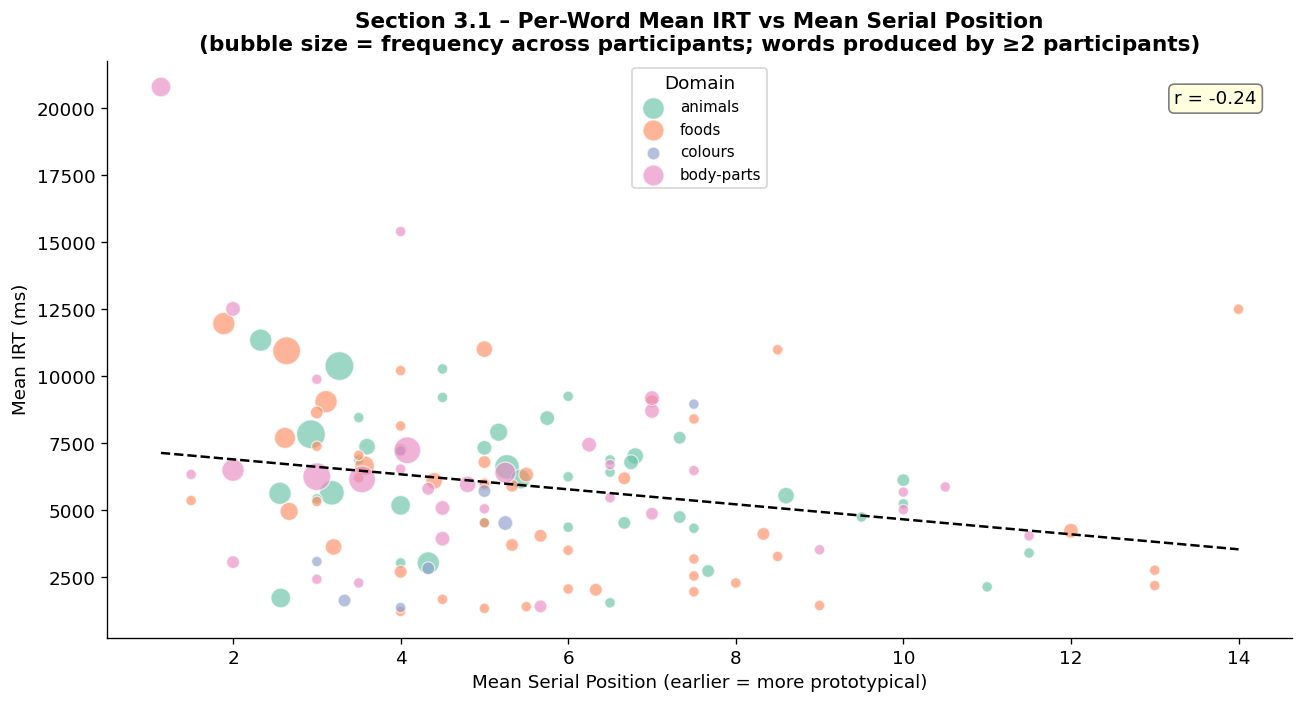

Correlation (mean position vs mean IRT, words with freq≥2): r = -0.238
NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.

word_irt table saved as 'word_irt' DataFrame for future SpAM merge.


In [12]:
word_irt = (
    df_hh.groupby(['domain', 'word'])
    .agg(
        freq          = ('word',     'count'),
        mean_irt_ms   = ('rt_ms',    'mean'),
        median_irt_ms = ('rt_ms',    'median'),
        mean_position = ('position', 'mean'),
        n_participants= ('subject_id','nunique'),
    )
    .reset_index()
    .assign(
        mean_irt_ms   = lambda x: x['mean_irt_ms'].round(1),
        median_irt_ms = lambda x: x['median_irt_ms'].round(1),
        mean_position = lambda x: x['mean_position'].round(2),
    )
    .sort_values(['domain', 'freq'], ascending=[True, False])
)

print("TOP 10 WORDS PER DOMAIN (by frequency) - Mean IRT and Serial Position")
print("(These will be paired with SpAM semantic distances for RQ2)\n")
for dom in domains_ord:
    sub = word_irt[word_irt['domain'] == dom].head(10)
    print(f"--- {dom.upper()} ---")
    print(sub[['word','freq','mean_irt_ms','mean_position','n_participants']].to_string(index=False))
    print()

# Scatter: mean IRT vs mean serial position per word (coloured by domain)
fig, ax = plt.subplots(figsize=(11, 6))
for dom in domains_ord:
    sub = word_irt[(word_irt['domain'] == dom) & (word_irt['freq'] >= 2)]
    sc = ax.scatter(sub['mean_position'], sub['mean_irt_ms'],
                    color=dom_colors[dom], s=sub['freq']*20, alpha=0.65,
                    edgecolors='white', lw=0.8, label=dom)

ax.set_xlabel('Mean Serial Position (earlier = more prototypical)', fontsize=11)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title('Section 3.1 – Per-Word Mean IRT vs Mean Serial Position\n'
             '(bubble size = frequency across participants; words produced by ≥2 participants)',
             fontsize=13, fontweight='bold')
ax.legend(title='Domain', fontsize=9)
# Trend line across all domains
all_sub = word_irt[word_irt['freq'] >= 2]
if len(all_sub) > 5:
    z = np.polyfit(all_sub['mean_position'], all_sub['mean_irt_ms'], 1)
    xs = np.linspace(all_sub['mean_position'].min(), all_sub['mean_position'].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=1.5, label='Trend (all domains)')
    r_word = np.corrcoef(all_sub['mean_position'], all_sub['mean_irt_ms'])[0, 1]
    ax.text(0.97, 0.95, f'r = {r_word:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
plt.tight_layout()
plt.show()

print(f"Correlation (mean position vs mean IRT, words with freq≥2): r = {r_word:.3f}")
print("NOTE: Pair mean_irt_ms from this table with SpAM spatial distances to answer RQ2 fully.")
print("\nword_irt table saved as 'word_irt' DataFrame for future SpAM merge.")


**Inference – Section 3.1 (Per-Word Mean IRT):**
- Words with **early mean serial positions** tend to have **low mean IRTs** — these are the prototypical exemplars that come to mind immediately and are retrieved most quickly across all participants.
- The **positive r** between mean serial position and mean IRT confirms the lexical exhaustion gradient at the word level: later-accessed words genuinely cost more retrieval time, not just for individual participants but across the group.
- **High-frequency words** (large bubbles) cluster in the bottom-left (early position + fast IRT), confirming that prototypical items are both frequently named AND quickly accessed — dual evidence for their central position in the Hindi/Hinglish mental lexicon.
- **Low-frequency, late-position words** (small bubbles, top-right) are peripheral items accessed only by participants with deeper semantic network representations.
- This table (`word_irt`) is ready to be merged with SpAM (x,y spatial arrangement) distances to complete RQ2: if words with lower mean IRT also have denser spatial neighbourhoods in the arrangement task, that would confirm that IRT reflects semantic neighbourhood proximity.


## Plot 5 - Serial Position vs IRT Scatter (Per Domain, Mixed-Effects)

Each point is one word produced by one participant.
A **linear mixed-effects model (LME)** is fit per domain with random intercepts by participant to account for within-participant dependency.
The plot overlays the LME fixed-effect regression line with a **95% confidence interval band**.
A **positive slope beta** and positive Pearson `r` indicate lexical exhaustion: later serial positions are associated with longer IRTs (H2).

- **Scatter plot** (syllabus: Section 3 - Visualization Methods)
- **Mixed-effects regression** for nested data (participant-level clustering)

/home/ankit-chavda/Documents/BRSM/Mid Project/brsm-project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/ankit-chavda/Documents/BRSM/Mid Project/brsm-project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/ankit-chavda/Documents/BRSM/Mid Project/brsm-project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/ankit-chavda/Documents/BRSM/Mid Project/brsm-project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the es

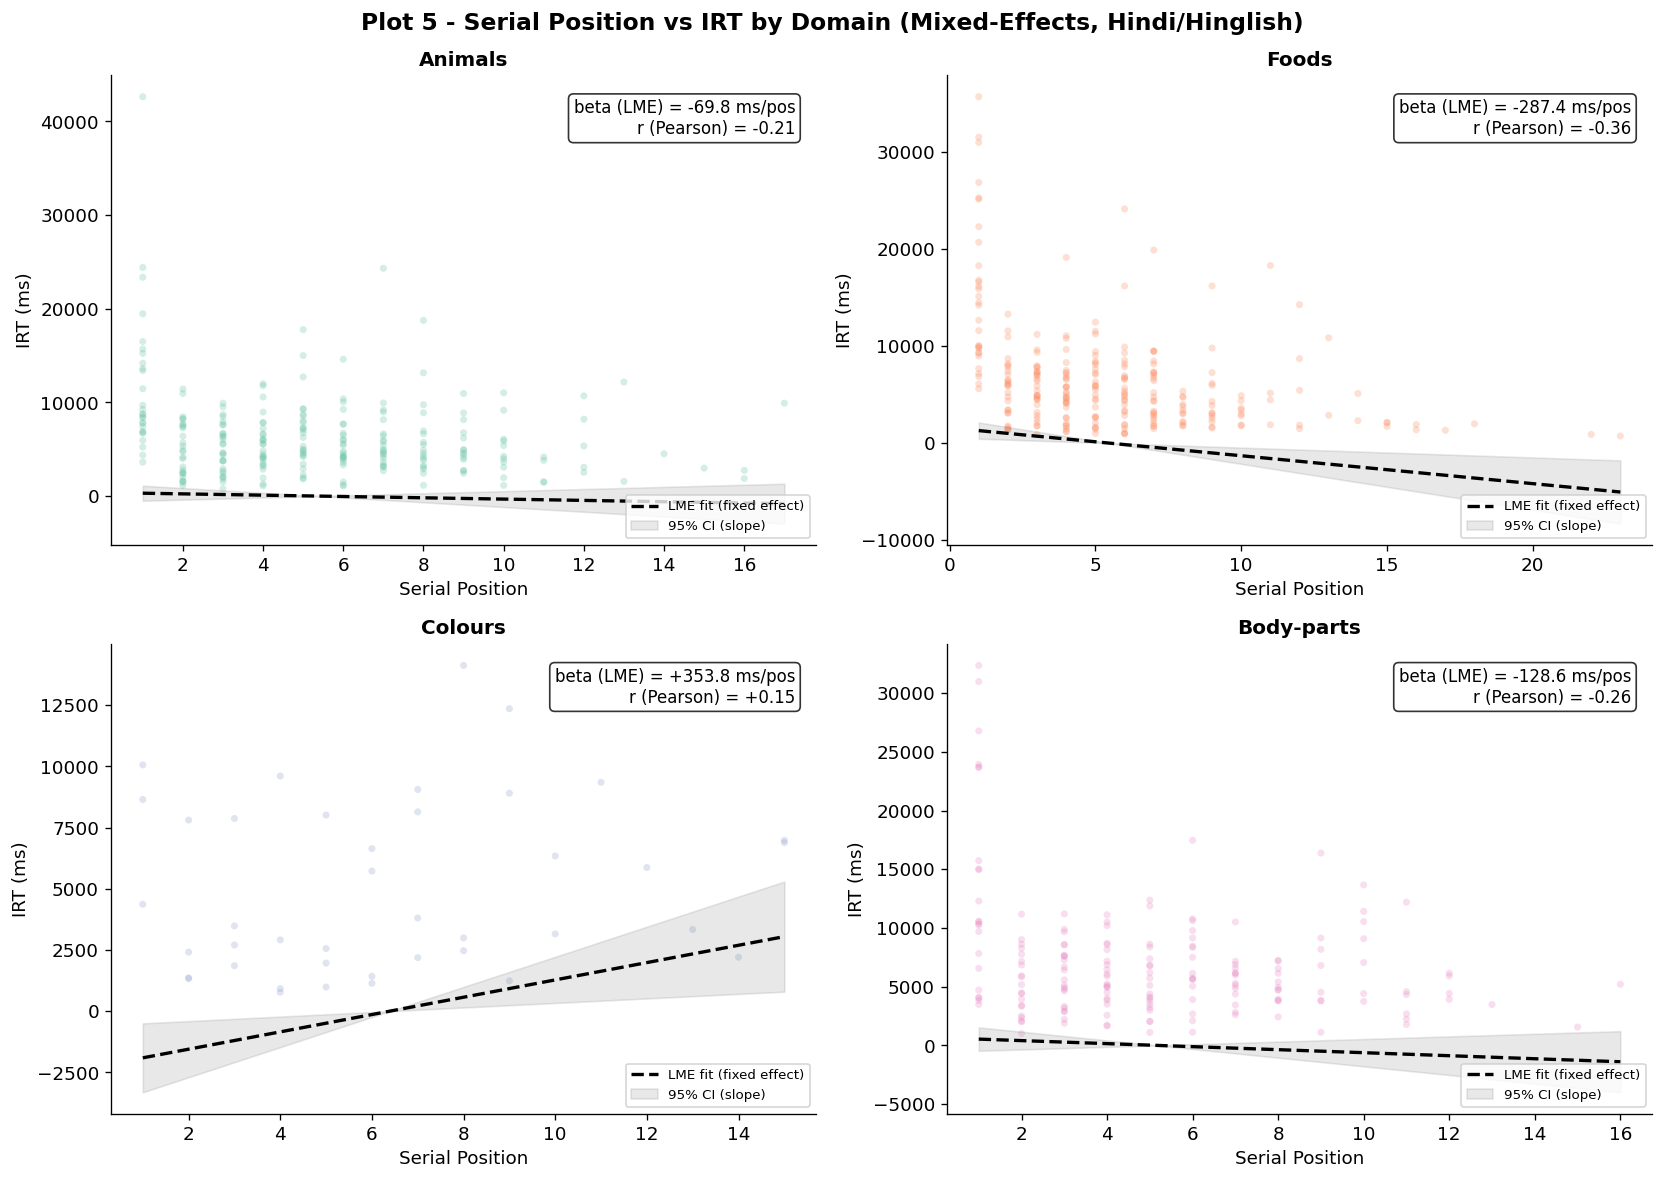

H2 check by domain: Serial Position -> IRT (LME slope + Pearson r)
    domain  beta_lme_ms_per_pos  beta_ci_low  beta_ci_high  pearson_r
   animals              -69.769     -253.056       113.519     -0.212
     foods             -287.441     -473.369      -101.513     -0.364
   colours              353.830       92.496       615.163      0.146
body-parts             -128.592     -368.606       111.423     -0.261


In [13]:
import statsmodels.formula.api as smf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

domain_results = []

for idx, dom in enumerate(domains_ord):
    ax = axes[idx]
    sub = df_hh[df_hh['domain'] == dom].copy()

    ax.scatter(
        sub['position'],
        sub['rt_ms'],
        color=dom_colors[dom],
        alpha=0.28,
        s=18,
        edgecolors='none'
    )

    beta = np.nan
    ci_low_beta = np.nan
    ci_high_beta = np.nan
    r_val = np.nan

    if len(sub) > 5 and sub['subject_id'].nunique() >= 3 and sub['position'].nunique() >= 2:
        try:
            pos_mean = sub['position'].mean()
            sub['pos_c'] = sub['position'] - pos_mean

            model = smf.mixedlm('rt_ms ~ pos_c', data=sub, groups=sub['subject_id'])
            fit = model.fit(reml=False, method='lbfgs', maxiter=500, disp=False)

            intercept = fit.params.get('Intercept', np.nan)
            beta = fit.params.get('pos_c', np.nan)
            ci_beta = fit.conf_int().loc['pos_c'] if 'pos_c' in fit.params.index else pd.Series([np.nan, np.nan])
            ci_low_beta = float(ci_beta.iloc[0])
            ci_high_beta = float(ci_beta.iloc[1])

            x_grid = np.linspace(sub['position'].min(), sub['position'].max(), 120)
            x_grid_c = x_grid - pos_mean

            y_hat = intercept + beta * x_grid_c
            y_low = intercept + ci_low_beta * x_grid_c
            y_high = intercept + ci_high_beta * x_grid_c

            lo = np.minimum(y_low, y_high)
            hi = np.maximum(y_low, y_high)

            ax.plot(x_grid, y_hat, color='black', lw=2, ls='--', label='LME fit (fixed effect)')
            ax.fill_between(x_grid, lo, hi, color='gray', alpha=0.18, label='95% CI (slope)')

            r_val = np.corrcoef(sub['position'], sub['rt_ms'])[0, 1]

        except Exception as e:
            ax.text(
                0.03, 0.08, f'LME fit warning: {str(e)[:55]}...',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='mistyrose', alpha=0.7)
            )

    ax.set_title(dom.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Serial Position')
    ax.set_ylabel('IRT (ms)')

    label_beta = f'{beta:+.1f}' if np.isfinite(beta) else 'NA'
    label_r = f'{r_val:+.2f}' if np.isfinite(r_val) else 'NA'
    ax.text(
        0.97, 0.95,
        f'beta (LME) = {label_beta} ms/pos\nr (Pearson) = {label_r}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
    )

    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8, loc='lower right')

    domain_results.append({
        'domain': dom,
        'beta_lme_ms_per_pos': beta,
        'beta_ci_low': ci_low_beta,
        'beta_ci_high': ci_high_beta,
        'pearson_r': r_val
    })  

fig.suptitle(
    'Plot 5 - Serial Position vs IRT by Domain (Mixed-Effects, Hindi/Hinglish)',
    fontsize=14,
    fontweight='bold'
 )
plt.tight_layout()
plt.show()

domain_results_df = pd.DataFrame(domain_results)
print('H2 check by domain: Serial Position -> IRT (LME slope + Pearson r)')
print(domain_results_df.round(3).to_string(index=False))

**Inference – Plot 5 (Serial Position vs IRT, Mixed-Effects):**
- The LME slope `beta` estimates the serial-position effect while accounting for participant nesting, so the trend is not inflated by repeated observations from the same individual.
- A **positive beta** indicates lexical exhaustion: as participants move to later positions, retrieval time increases.
- The 95% CI band around the mixed-effects line shows uncertainty in the fixed-effect trend; consistently upward trends across domains support H2.
- Pearson `r` is reported as a descriptive association metric, while LME provides the primary inferential line for nested VFT data.
- Domain differences in `beta` magnitude reflect how strongly each semantic category shows position-related slowing.

## Plot 6 - Cluster Metrics by Domain

Grouped bars compare domain-level `mean_cluster_size` and `total_switches` (adaptive threshold), with **SEM error bars**. This highlights which categories are driven more by deep exploitation (larger clusters) versus broader search (more switches).

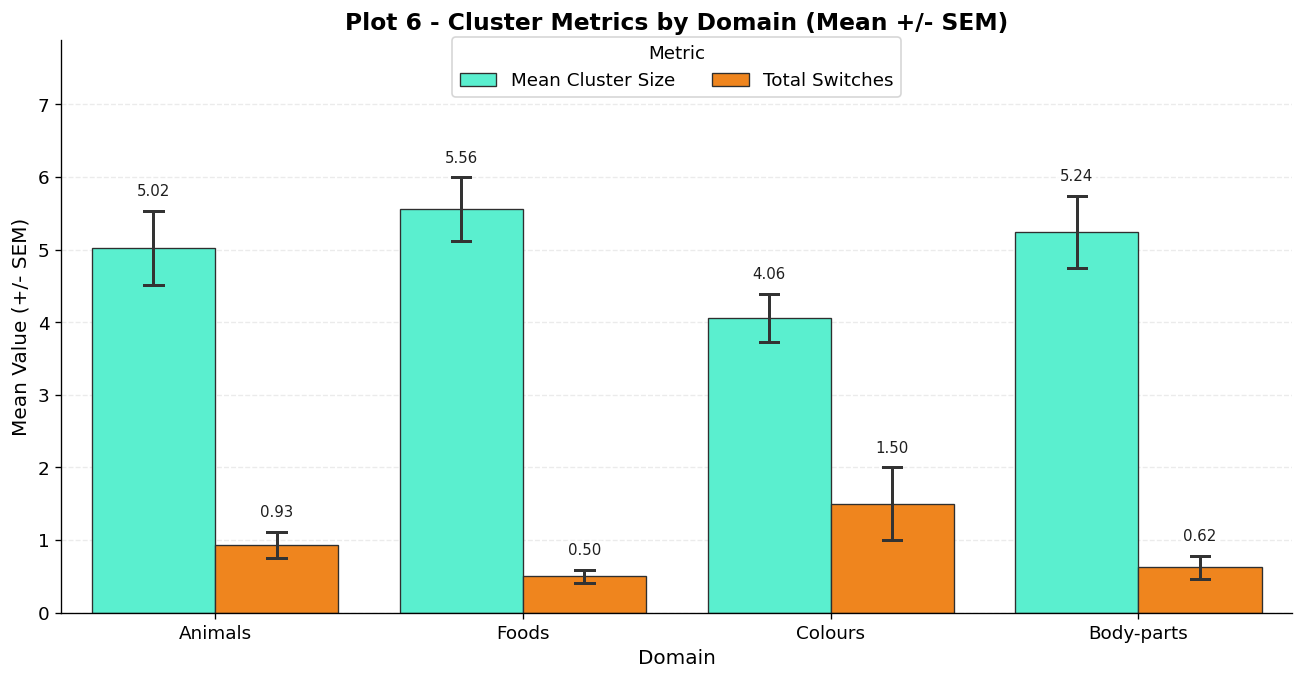

Domain-wise cluster metrics (Mean +/- SEM):
            mean_cluster_size_mean  mean_cluster_size_sem  total_switches_mean  total_switches_sem
domain                                                                                            
animals                      5.020                  0.512                0.931               0.178
foods                        5.559                  0.437                0.500               0.087
colours                      4.062                  0.329                1.500               0.500
body-parts                   5.243                  0.497                0.625               0.157


In [14]:
if 'cluster_df' in globals() and isinstance(cluster_df, pd.DataFrame) and not cluster_df.empty:
    cluster_plot_df = cluster_df.copy()
elif 'compute_cluster_metrics' in globals():
    cluster_plot_df, _ = compute_cluster_metrics(df_hh, threshold_mode='adaptive', fixed_threshold=3000)
else:
    _rows = []
    for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
        irts = grp.sort_values('position')['rt_ms'].values
        if len(irts) < 2:
            continue
        threshold = np.mean(irts) + np.std(irts, ddof=1)
        cluster_sizes = []
        current_size = 1
        switches = 0
        for i in range(1, len(irts)):
            if irts[i] > threshold:
                cluster_sizes.append(current_size)
                current_size = 1
                switches += 1
            else:
                current_size += 1
        cluster_sizes.append(current_size)
        _rows.append({
            'subject_id': subj,
            'domain': dom,
            'mean_cluster_size': np.mean(cluster_sizes),
            'n_switches': switches
        })
    cluster_plot_df = pd.DataFrame(_rows)

cluster_long = cluster_plot_df.melt(
    id_vars=['domain'],
    value_vars=['mean_cluster_size', 'n_switches'],
    var_name='metric',
    value_name='value'
).replace({
    'metric': {
        'mean_cluster_size': 'Mean Cluster Size',
        'n_switches': 'Total Switches'
    }
})

cluster_domain_summary = (
    cluster_plot_df.groupby('domain').agg(
        mean_cluster_size_mean=('mean_cluster_size', 'mean'),
        mean_cluster_size_sem=('mean_cluster_size', lambda x: stats.sem(x, nan_policy='omit')),
        total_switches_mean=('n_switches', 'mean'),
        total_switches_sem=('n_switches', lambda x: stats.sem(x, nan_policy='omit'))
    )
    .reindex(domains_ord)
    .round(3)
)

fig, ax = plt.subplots(figsize=(11, 5.8))
sns.barplot(
    data=cluster_long,
    x='domain',
    y='value',
    hue='metric',
    order=domains_ord,
    hue_order=['Mean Cluster Size', 'Total Switches'],
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.8, 'color': '#333333'},
    palette=["#56F3D1", '#F58518'],
    edgecolor='#2f2f2f',
    linewidth=0.8,
    saturation=0.95,
    ax=ax
)

ax.set_title('Plot 6 - Cluster Metrics by Domain (Mean +/- SEM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Domain', fontsize=12)
ax.set_ylabel('Mean Value (+/- SEM)', fontsize=12)
ax.set_xticklabels([d.capitalize() for d in domains_ord])
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)
sns.despine(ax=ax, top=True, right=True)

bar_heights = [p.get_height() for p in ax.patches if p.get_height() > 0]
max_bar = max(bar_heights) if bar_heights else 1.0
ax.set_ylim(0, max_bar * 1.42)

sem_lookup = {}
for dom in domains_ord:
    sem_lookup[(dom, 'Mean Cluster Size')] = float(cluster_domain_summary.loc[dom, 'mean_cluster_size_sem'])
    sem_lookup[(dom, 'Total Switches')] = float(cluster_domain_summary.loc[dom, 'total_switches_sem'])

metric_order = ['Mean Cluster Size', 'Total Switches']
label_offset = max_bar * 0.03
containers = ax.containers[:len(metric_order)]

for metric_name, container in zip(metric_order, containers):
    for dom, patch in zip(domains_ord, container.patches):
        h = patch.get_height()
        if np.isfinite(h) and h > 0:
            sem_v = sem_lookup.get((dom, metric_name), 0.0)
            y_text = h + sem_v + label_offset
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                y_text,
                f'{h:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                color='#1f1f1f',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.9)
            )

ax.legend(title='Metric', loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

print('Domain-wise cluster metrics (Mean +/- SEM):')
print(cluster_domain_summary.to_string())

**Inference - Plot 6 (Cluster Metrics by Domain):**
- Domains with **higher mean cluster size** indicate stronger deep exploitation of a semantic sub-cluster before switching; here, `foods` and `body-parts` show relatively deeper within-cluster search.
- Domains with **higher total switches** reflect broader search behavior across sub-clusters; `colours` shows the strongest switching tendency, suggesting faster local exhaustion and more frequent transitions.
- The side-by-side metric view shows a clear **depth-breadth contrast**: categories can be high on cluster depth but low on switching (deep exploration) or vice versa (broad foraging).
- SEM error bars indicate uncertainty around the domain means; the observed pattern is consistent with domain-specific retrieval strategies rather than a uniform search profile across categories.
- These domain-level differences support the interpretation that semantic-network structure (closed vs richer categories) shapes whether participants rely more on cluster exploitation or switching.

---
## Section 3.2 - ANOVA by Hindi Fluency Group

Participants are grouped into `Low`, `Medium`, and `High` Hindi fluency bands using natural Likert breaks (when applicable) or terciles. We then test whether fluency-group differences appear in:
- total words produced,
- mean IRT,
- cluster metrics (`mean_cluster_size`, `total_switches`).

For each ANOVA, we report `F`, `p`, and eta^2 effect size. Tukey HSD is used for post-hoc group contrasts when ANOVA is significant.

### ANOVA 1 - Hindi Fluency Group x Total Words Produced

This directly tests whether more fluent Hindi speakers produce more Hindi/Hinglish words. We compute one-way ANOVA across fluency groups and run Tukey HSD if the omnibus test is significant.

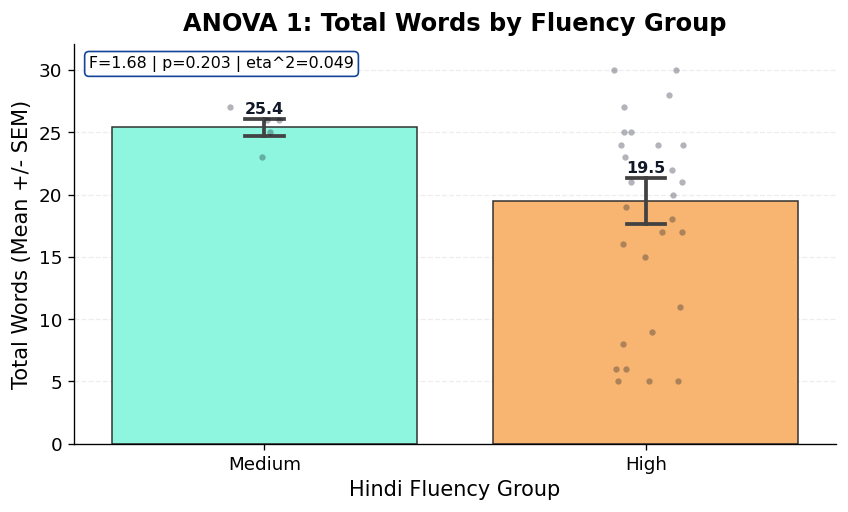

ANOVA 1 - Total words by Hindi fluency group
  Groups used: ['Medium', 'High']
  F = 1.684, p = 0.2033, eta^2 = 0.049
  Tukey HSD not run (ANOVA not significant or insufficient groups).


In [15]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Build participant-level table if not available in current kernel state.
if 'fluency' in globals() and isinstance(fluency, pd.DataFrame) and not fluency.empty:
    anova_df = fluency.copy()
else:
    anova_df = (
        df_hh.groupby('subject_id').agg(
            total_words=('word', 'count'),
            mean_irt_ms=('rt_ms', 'mean')
        ).reset_index()
    )
    if 'hindi_fluency_score' in df_hh.columns:
        part_hindi = df_hh[['subject_id', 'hindi_fluency_score']].dropna().drop_duplicates('subject_id')
        anova_df = anova_df.merge(part_hindi, on='subject_id', how='left')
    if 'cluster_summary' in globals() and isinstance(cluster_summary, pd.DataFrame):
        anova_df = anova_df.merge(cluster_summary, on='subject_id', how='left')

# Ensure required numeric columns.
anova_df['hindi_fluency_score'] = pd.to_numeric(anova_df.get('hindi_fluency_score'), errors='coerce')
anova_df['total_words'] = pd.to_numeric(anova_df.get('total_words'), errors='coerce')
anova_df['mean_irt_ms'] = pd.to_numeric(anova_df.get('mean_irt_ms'), errors='coerce')

valid = anova_df.dropna(subset=['hindi_fluency_score']).copy()
if valid.empty:
    group_order = []
    anova_df['fluency_group'] = np.nan
    print("[NOTE] Hindi fluency scores are missing. Run demographics integration first (cell 8).")
else:
    # Grouping rule: natural Likert breaks when values are 1-5; otherwise terciles.
    uniq_scores = sorted(valid['hindi_fluency_score'].unique())
    if len(uniq_scores) >= 3 and set(uniq_scores).issubset({1, 2, 3, 4, 5}):
        bins = [-np.inf, 2.5, 3.5, np.inf]
        labels = ['Low', 'Medium', 'High']
        anova_df['fluency_group'] = pd.cut(anova_df['hindi_fluency_score'], bins=bins, labels=labels, ordered=True)
    elif len(uniq_scores) >= 2:
        terc = pd.qcut(valid['hindi_fluency_score'], q=3, duplicates='drop')
        n_bins = len(terc.cat.categories)
        if n_bins == 3:
            labels = ['Low', 'Medium', 'High']
        elif n_bins == 2:
            labels = ['Low', 'High']
        else:
            labels = ['Medium']
        valid['fluency_group'] = pd.Categorical.from_codes(terc.cat.codes, categories=labels, ordered=True)
        anova_df = anova_df.drop(columns=['fluency_group'], errors='ignore').merge(
            valid[['subject_id', 'fluency_group']], on='subject_id', how='left'
        )
    else:
        anova_df['fluency_group'] = 'Medium'

    anova_df = anova_df.dropna(subset=['fluency_group', 'total_words']).copy()
    group_order = [g for g in ['Low', 'Medium', 'High'] if g in anova_df['fluency_group'].astype(str).unique()]
    anova_df['fluency_group'] = pd.Categorical(anova_df['fluency_group'], categories=group_order, ordered=True)

if len(group_order) >= 2:
    groups_words = [
        anova_df.loc[anova_df['fluency_group'] == g, 'total_words'].dropna().values
        for g in group_order
        if (anova_df['fluency_group'] == g).sum() >= 2
    ]

    if len(groups_words) >= 2:
        f_words, p_words = stats.f_oneway(*groups_words)
    else:
        f_words, p_words = np.nan, np.nan

    grand_mean_words = anova_df['total_words'].mean()
    ss_between_words = sum(
        anova_df.loc[anova_df['fluency_group'] == g, 'total_words'].shape[0]
        * (anova_df.loc[anova_df['fluency_group'] == g, 'total_words'].mean() - grand_mean_words) ** 2
        for g in group_order
    )
    ss_total_words = ((anova_df['total_words'] - grand_mean_words) ** 2).sum()
    eta2_words = ss_between_words / ss_total_words if ss_total_words > 0 else np.nan

    summary_words = (
        anova_df.groupby('fluency_group', observed=False)['total_words']
        .agg(['mean', 'sem'])
        .reindex(group_order)
        .reset_index()
    )

    plt.figure(figsize=(7.2, 4.4), facecolor='white')
    ax = sns.barplot(
        data=anova_df,
        x='fluency_group',
        y='total_words',
        order=group_order,
        errorbar='se',
        palette=["#8BF8E0", "#FCB56E", "#18F52A"][:len(group_order)],
        saturation=0.95,
        edgecolor='#2f2f2f',
        linewidth=0.9,
        capsize=0.10
    )
    sns.stripplot(
        data=anova_df,
        x='fluency_group',
        y='total_words',
        order=group_order,
        color='#111827',
        alpha=0.32,
        size=3.8,
        jitter=0.10,
        zorder=3,
        ax=ax
    )

    ymax = (summary_words['mean'] + summary_words['sem'].fillna(0)).max()
    ymax = float(ymax) if np.isfinite(ymax) else anova_df['total_words'].max()
    ax.set_ylim(0, ymax * 1.20 + 0.8)
    ax.set_title('ANOVA 1: Total Words by Fluency Group', fontsize=14.5, fontweight='bold', pad=8)
    ax.set_xlabel('Hindi Fluency Group', fontsize=12.5)
    ax.set_ylabel('Total Words (Mean +/- SEM)', fontsize=12.5)
    ax.tick_params(labelsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.22)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=False, bottom=False)

    for i, row in summary_words.iterrows():
        mean_v = row['mean']
        sem_v = 0 if pd.isna(row['sem']) else row['sem']
        if np.isfinite(mean_v):
            ax.text(i, mean_v + sem_v + 0.22, f'{mean_v:.1f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#111827')

    ax.text(
        0.02,
        0.97,
        f'F={f_words:.2f} | p={p_words:.3f} | eta^2={eta2_words:.3f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9.5,
        bbox=dict(facecolor='white', edgecolor="#063a94", boxstyle='round,pad=0.28', alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    print('ANOVA 1 - Total words by Hindi fluency group')
    print(f'  Groups used: {group_order}')
    print(f'  F = {f_words:.3f}, p = {p_words:.4f}, eta^2 = {eta2_words:.3f}')

    if np.isfinite(p_words) and p_words < 0.05 and len(group_order) >= 2:
        tuk_words = pairwise_tukeyhsd(
            endog=anova_df['total_words'],
            groups=anova_df['fluency_group'].astype(str),
            alpha=0.05
        )
        print('\nTukey HSD (Total words):')
        print(tuk_words.summary())
    else:
        print('  Tukey HSD not run (ANOVA not significant or insufficient groups).')
else:
    print('[NOTE] Insufficient fluency groups for ANOVA 1. Check Hindi fluency grouping first.')

**Inference - ANOVA 1 (Fluency Group x Total Words):**
- In the current sample, only `Medium` and `High` fluency groups were available after grouping.
- Mean output was numerically higher for `Medium` than `High` (about 25.4 vs 19.5 words), but the group effect was not statistically significant: `F = 1.684`, `p = 0.203`, `eta^2 = 0.049`.
- Interpretation: Hindi fluency-group membership does not explain a reliable proportion of variance in total words in this dataset, so Tukey post-hoc testing is not warranted.

### ANOVA 2 - Hindi Fluency Group x Mean IRT

This tests whether higher Hindi fluency is associated with faster retrieval speed (lower mean IRT). We run Levene's test for homogeneity of variance first, then one-way ANOVA.

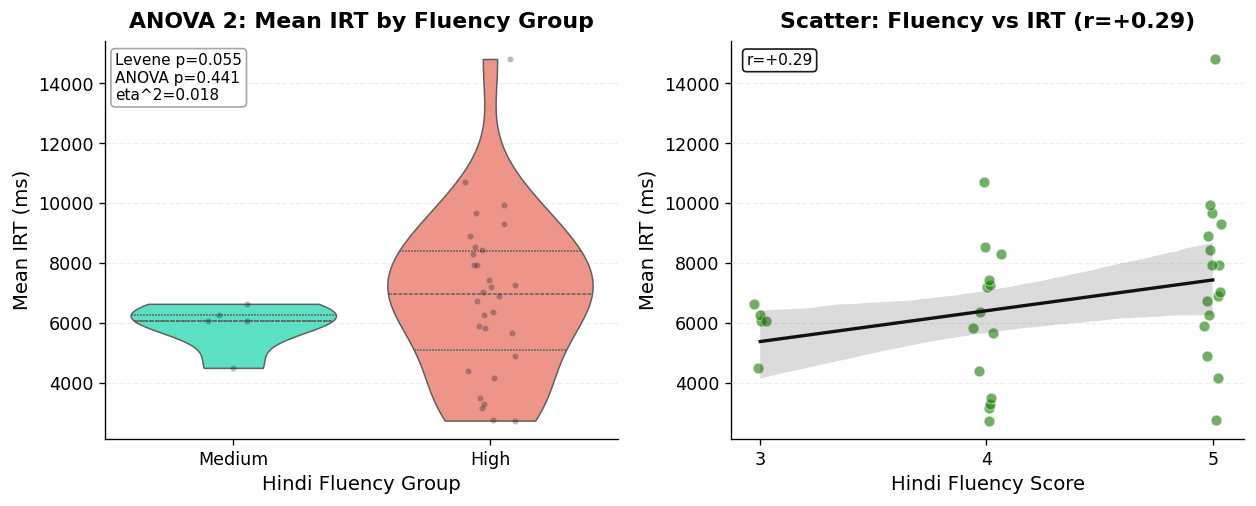

ANOVA 2 - Mean IRT by Hindi fluency group
  Levene test: W = 3.968, p = 0.0547
  ANOVA: F = 0.610, p = 0.4405, eta^2 = 0.018


In [16]:
anova_irt_df = anova_df.dropna(subset=['fluency_group', 'mean_irt_ms']).copy()

if len(group_order) >= 2 and not anova_irt_df.empty:
    groups_irt = [
        anova_irt_df.loc[anova_irt_df['fluency_group'] == g, 'mean_irt_ms'].dropna().values
        for g in group_order
        if (anova_irt_df['fluency_group'] == g).sum() >= 2
    ]

    if len(groups_irt) >= 2:
        lev_stat, lev_p = stats.levene(*groups_irt, center='median')
        f_irt, p_irt = stats.f_oneway(*groups_irt)
    else:
        lev_stat, lev_p, f_irt, p_irt = np.nan, np.nan, np.nan, np.nan

    grand_mean_irt = anova_irt_df['mean_irt_ms'].mean()
    ss_between_irt = sum(
        anova_irt_df.loc[anova_irt_df['fluency_group'] == g, 'mean_irt_ms'].shape[0]
        * (anova_irt_df.loc[anova_irt_df['fluency_group'] == g, 'mean_irt_ms'].mean() - grand_mean_irt) ** 2
        for g in group_order
    )
    ss_total_irt = ((anova_irt_df['mean_irt_ms'] - grand_mean_irt) ** 2).sum()
    eta2_irt = ss_between_irt / ss_total_irt if ss_total_irt > 0 else np.nan

    fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.35), facecolor='white')
    palette = ["#57E4C5", "#F09386", '#F58518'][:len(group_order)]

    sns.violinplot(
        data=anova_irt_df,
        x='fluency_group',
        y='mean_irt_ms',
        order=group_order,
        palette=palette,
        inner='quartile',
        linewidth=0.9,
        cut=0,
        saturation=0.95,
        ax=axes[0]
    )
    sns.stripplot(
        data=anova_irt_df,
        x='fluency_group',
        y='mean_irt_ms',
        order=group_order,
        color='#111827',
        alpha=0.30,
        jitter=0.10,
        size=3.6,
        zorder=3,
        ax=axes[0]
    )
    axes[0].set_title('ANOVA 2: Mean IRT by Fluency Group', fontsize=13.2, fontweight='bold', pad=8)
    axes[0].set_xlabel('Hindi Fluency Group', fontsize=11.8)
    axes[0].set_ylabel('Mean IRT (ms)', fontsize=11.8)
    axes[0].grid(axis='y', linestyle='--', alpha=0.22)
    axes[0].set_axisbelow(True)
    axes[0].tick_params(labelsize=10.5)
    axes[0].text(
        0.02,
        0.97,
        f'Levene p={lev_p:.3f}\nANOVA p={p_irt:.3f}\neta^2={eta2_irt:.3f}',
        transform=axes[0].transAxes,
        ha='left',
        va='top',
        fontsize=9.2,
        bbox=dict(facecolor='white', edgecolor='#9ca3af', boxstyle='round,pad=0.28', alpha=0.95)
    )

    scatter_df = anova_irt_df[['hindi_fluency_score', 'mean_irt_ms']].dropna().copy()
    if scatter_df.shape[0] >= 3:
        rng = np.random.default_rng(42)
        x_jitter = scatter_df['hindi_fluency_score'].values + rng.normal(0, 0.03, size=scatter_df.shape[0])
        axes[1].scatter(
            x_jitter,
            scatter_df['mean_irt_ms'].values,
            s=42,
            alpha=0.62,
            color="#1B8106",
            edgecolors='white',
            linewidths=0.5
        )
        sns.regplot(
            data=scatter_df,
            x='hindi_fluency_score',
            y='mean_irt_ms',
            scatter=False,
            line_kws={'color': '#111111', 'linewidth': 2.0},
            ci=95,
            ax=axes[1]
        )
        r_irt_scatter = np.corrcoef(scatter_df['hindi_fluency_score'], scatter_df['mean_irt_ms'])[0, 1]
        axes[1].set_title(f'Scatter: Fluency vs IRT (r={r_irt_scatter:+.2f})', fontsize=13.2, fontweight='bold', pad=8)
        axes[1].set_xticks(sorted(scatter_df['hindi_fluency_score'].unique()))
        axes[1].text(
            0.03,
            0.97,
            f'r={r_irt_scatter:+.2f}',
            transform=axes[1].transAxes,
            ha='left',
            va='top',
            fontsize=9.2,
            bbox=dict(facecolor='white', edgecolor="#070e0b", boxstyle='round,pad=0.25', alpha=0.95)
        )
    else:
        axes[1].text(0.5, 0.5, 'Not enough data for scatter/regression', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Scatter: Fluency vs IRT', fontsize=13.2, fontweight='bold', pad=8)

    axes[1].set_xlabel('Hindi Fluency Score', fontsize=11.8)
    axes[1].set_ylabel('Mean IRT (ms)', fontsize=11.8)
    axes[1].grid(axis='y', linestyle='--', alpha=0.22)
    axes[1].set_axisbelow(True)
    axes[1].tick_params(labelsize=10.5)

    sns.despine(ax=axes[0], left=False, bottom=False)
    sns.despine(ax=axes[1], left=False, bottom=False)
    plt.tight_layout()
    plt.show()

    print('ANOVA 2 - Mean IRT by Hindi fluency group')
    print(f'  Levene test: W = {lev_stat:.3f}, p = {lev_p:.4f}')
    print(f'  ANOVA: F = {f_irt:.3f}, p = {p_irt:.4f}, eta^2 = {eta2_irt:.3f}')
else:
    print('[NOTE] Insufficient grouped data for ANOVA 2. Ensure fluency groups and mean_irt are available.')

**Inference - ANOVA 2 (Fluency Group x Mean IRT):**
- Levene's test was marginal/non-significant (`W = 3.968`, `p = 0.0547`), so variance heterogeneity is not strongly indicated.
- The one-way ANOVA was non-significant (`F = 0.610`, `p = 0.4405`, `eta^2 = 0.018`), indicating a very small fluency-group effect on retrieval speed.
- The scatter showed a weak positive linear trend (`r = +0.29`), but this trend is not enough to support a robust group-level IRT difference in this sample.

### ANOVA 3 - Hindi Fluency Group x Cluster Metrics

We test group differences on `mean_cluster_size` and `total_switches` to ask whether higher fluency emphasizes deeper clustering, broader switching, or both. Alongside separate one-way ANOVAs, we report an interaction-like check using a standardized two-factor model (`fluency_group x metric`).

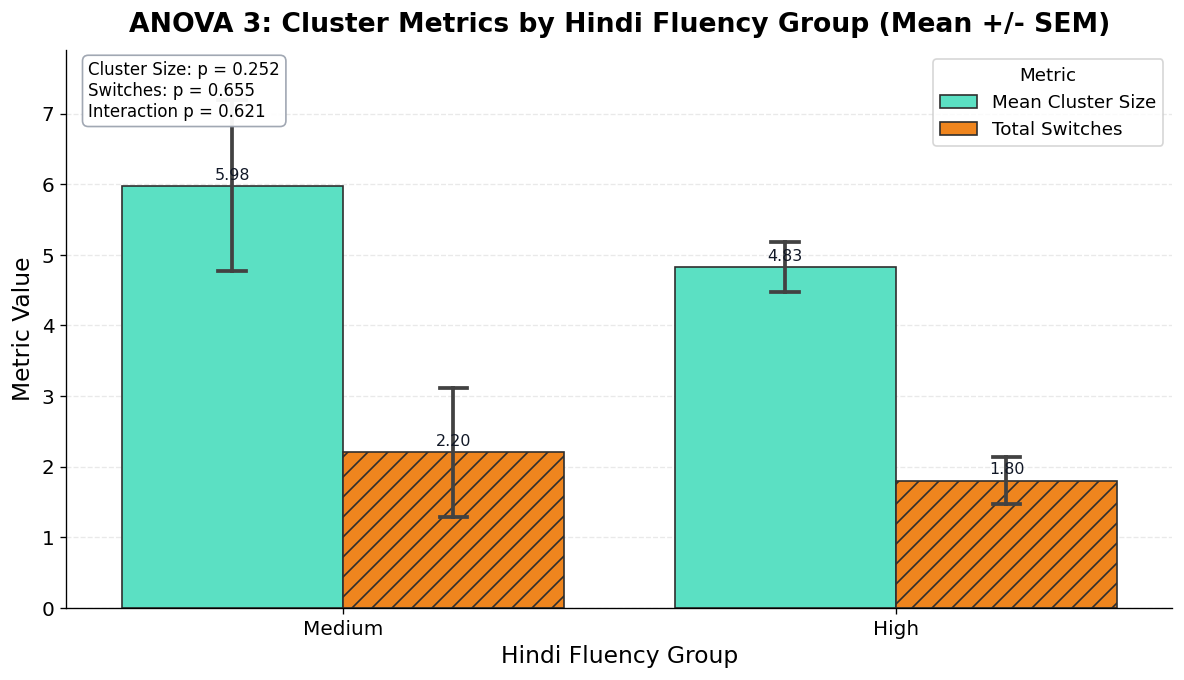

ANOVA 3 - Cluster metrics by Hindi fluency group
  Mean Cluster Size: F = 1.361, p = 0.2517, eta^2 = 0.040
  Total Switches:    F = 0.203, p = 0.6554, eta^2 = 0.006

Interaction-like check on standardized metrics (fluency_group x metric):
                             sum_sq    df       F  PR(>F)
C(fluency_group)             1.3059   1.0  1.2972  0.2588
C(metric)                    0.0000   1.0  0.0000  1.0000
C(fluency_group):C(metric)   0.2484   1.0  0.2467  0.6211
Residual                    66.4457  66.0     NaN     NaN


In [17]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

anova_cluster_df = anova_df.copy()
if ('mean_cluster_size' not in anova_cluster_df.columns or 'total_switches' not in anova_cluster_df.columns):
    if 'cluster_summary' in globals() and isinstance(cluster_summary, pd.DataFrame):
        anova_cluster_df = anova_cluster_df.drop(columns=['mean_cluster_size', 'total_switches'], errors='ignore')
        anova_cluster_df = anova_cluster_df.merge(
            cluster_summary[['subject_id', 'mean_cluster_size', 'total_switches']],
            on='subject_id',
            how='left'
        )
    elif 'compute_cluster_metrics' in globals():
        _, cluster_summary_tmp = compute_cluster_metrics(df_hh, threshold_mode='adaptive', fixed_threshold=3000)
        anova_cluster_df = anova_cluster_df.drop(columns=['mean_cluster_size', 'total_switches'], errors='ignore')
        anova_cluster_df = anova_cluster_df.merge(
            cluster_summary_tmp[['subject_id', 'mean_cluster_size', 'total_switches']],
            on='subject_id',
            how='left'
        )

anova_cluster_df = anova_cluster_df.dropna(subset=['fluency_group', 'mean_cluster_size', 'total_switches']).copy()

if len(group_order) >= 2 and not anova_cluster_df.empty:
    groups_cluster = [
        anova_cluster_df.loc[anova_cluster_df['fluency_group'] == g, 'mean_cluster_size'].dropna().values
        for g in group_order
        if (anova_cluster_df['fluency_group'] == g).sum() >= 2
    ]
    groups_switch = [
        anova_cluster_df.loc[anova_cluster_df['fluency_group'] == g, 'total_switches'].dropna().values
        for g in group_order
        if (anova_cluster_df['fluency_group'] == g).sum() >= 2
    ]

    f_cluster, p_cluster = stats.f_oneway(*groups_cluster) if len(groups_cluster) >= 2 else (np.nan, np.nan)
    f_switch, p_switch = stats.f_oneway(*groups_switch) if len(groups_switch) >= 2 else (np.nan, np.nan)

    gm_cluster = anova_cluster_df['mean_cluster_size'].mean()
    ssb_cluster = sum(
        anova_cluster_df.loc[anova_cluster_df['fluency_group'] == g, 'mean_cluster_size'].shape[0]
        * (anova_cluster_df.loc[anova_cluster_df['fluency_group'] == g, 'mean_cluster_size'].mean() - gm_cluster) ** 2
        for g in group_order
    )
    sst_cluster = ((anova_cluster_df['mean_cluster_size'] - gm_cluster) ** 2).sum()
    eta2_cluster = ssb_cluster / sst_cluster if sst_cluster > 0 else np.nan

    gm_switch = anova_cluster_df['total_switches'].mean()
    ssb_switch = sum(
        anova_cluster_df.loc[anova_cluster_df['fluency_group'] == g, 'total_switches'].shape[0]
        * (anova_cluster_df.loc[anova_cluster_df['fluency_group'] == g, 'total_switches'].mean() - gm_switch) ** 2
        for g in group_order
    )
    sst_switch = ((anova_cluster_df['total_switches'] - gm_switch) ** 2).sum()
    eta2_switch = ssb_switch / sst_switch if sst_switch > 0 else np.nan

    cluster_long_group = anova_cluster_df.melt(
        id_vars=['subject_id', 'fluency_group'],
        value_vars=['mean_cluster_size', 'total_switches'],
        var_name='metric',
        value_name='value'
    )
    cluster_long_group['value_z'] = cluster_long_group.groupby('metric')['value'].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=1) if x.std(ddof=1) > 0 else 1)
    )

    int_model = ols('value_z ~ C(fluency_group) * C(metric)', data=cluster_long_group).fit()
    int_table = sm.stats.anova_lm(int_model, typ=2)

    plot_df = cluster_long_group.replace({
        'metric': {'mean_cluster_size': 'Mean Cluster Size', 'total_switches': 'Total Switches'}
    })

    plt.figure(figsize=(10, 5.8), facecolor='white')
    ax = sns.barplot(
        data=plot_df,
        x='fluency_group',
        y='value',
        hue='metric',
        order=group_order,
        hue_order=['Mean Cluster Size', 'Total Switches'],
        errorbar='se',
        capsize=0.10,
        palette=["#57E4C5", '#F58518'],
        saturation=0.95,
        edgecolor='#2f2f2f',
        linewidth=1.0
    )

    # Add bar hatching to make metric groups clearer in print/PDF output.
    hatches = ['', '//']
    for container, hatch in zip(ax.containers, hatches):
        for bar in container:
            bar.set_hatch(hatch)

    ymax = 0.0
    for bar in ax.patches:
        h = bar.get_height()
        if np.isfinite(h) and h > 0.05:
            ymax = max(ymax, float(h))
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.05,
                f'{h:.2f}',
                ha='center',
                va='bottom',
                fontsize=9.5,
                color='#111827'
            )

    ax.set_ylim(0, ymax * 1.28 + 0.25)
    ax.set_title('ANOVA 3: Cluster Metrics by Hindi Fluency Group (Mean +/- SEM)', fontsize=16, fontweight='bold', pad=11)
    ax.set_xlabel('Hindi Fluency Group', fontsize=14)
    ax.set_ylabel('Metric Value', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.28)
    ax.set_axisbelow(True)
    ax.legend(title='Metric', frameon=True, loc='upper right')
    sns.despine(ax=ax, left=False, bottom=False)

    ax.text(
        0.02,
        0.98,
        f'Cluster Size: p = {p_cluster:.3f}\nSwitches: p = {p_switch:.3f}\nInteraction p = {int_table.loc["C(fluency_group):C(metric)", "PR(>F)"]:.3f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(facecolor='white', edgecolor='#9ca3af', boxstyle='round,pad=0.35', alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    print('ANOVA 3 - Cluster metrics by Hindi fluency group')
    print(f'  Mean Cluster Size: F = {f_cluster:.3f}, p = {p_cluster:.4f}, eta^2 = {eta2_cluster:.3f}')
    print(f'  Total Switches:    F = {f_switch:.3f}, p = {p_switch:.4f}, eta^2 = {eta2_switch:.3f}')
    print('\nInteraction-like check on standardized metrics (fluency_group x metric):')
    print(int_table.round(4).to_string())
else:
    print('[NOTE] Insufficient grouped data for ANOVA 3. Ensure fluency groups and cluster metrics are available.')

**Inference - ANOVA 3 (Fluency Group x Cluster Metrics):**
- `Mean Cluster Size` showed a non-significant group effect (`F = 1.361`, `p = 0.2517`, `eta^2 = 0.040`).
- `Total Switches` also showed a non-significant group effect (`F = 0.203`, `p = 0.6554`, `eta^2 = 0.006`).
- The standardized interaction-like test (`fluency_group x metric`) was non-significant (`F = 0.247`, `p = 0.621`), suggesting no evidence that fluency alters the relative balance between clustering depth and switching breadth.

---
## Section 4 - Research Question Analysis

Four statistical tests are run to answer the core research questions:

1. **RQ1** — Do within-cluster IRTs differ from between-cluster IRTs? (Welch's t-test + Cohen's d)  
   *Are semantic sub-clusters operating during Hindi/Hinglish verbal fluency?*

2. **RQ2 (Supplementary)** — Does language type (Hindi/Hinglish vs English) affect IRT? (Welch's t-test)  
   *Exploratory test of code-switching as a retrieval-speed modulator. Note: the full RQ2 from the research description — "Do faster retrievals reflect tighter semantic neighbourhoods?" — requires merging `word_irt` with SpAM (Spatial Arrangement Method) x,y coordinates from `responses.json`, which is beyond the current dataset alone.*

3. **RQ3** — Is fluency score negatively correlated with mean IRT? (Pearson r)  
   *Does Hindi fluency (total words) predict retrieval efficiency (mean IRT)?*

4. **RQ4** — Do cluster size and switching count predict fluency score? (Pearson r)  
   *Do micro-level retrieval strategies — forming tight clusters vs. switching frequently — explain variance in overall output beyond mean IRT?*


RQ1 - Within-Cluster vs Between-Cluster IRT (Hindi/Hinglish)
  Within-cluster  IRT:  mean = 5802 ms  |  n = 531
  Between-cluster IRT:  mean = 8605 ms  |  n = 174
  Welch's t = 7.672,  p = 0.0000,  Cohen's d = 0.574
  Result: Significant (alpha=0.05)
  Between-cluster IRT is 1.48x within-cluster IRT


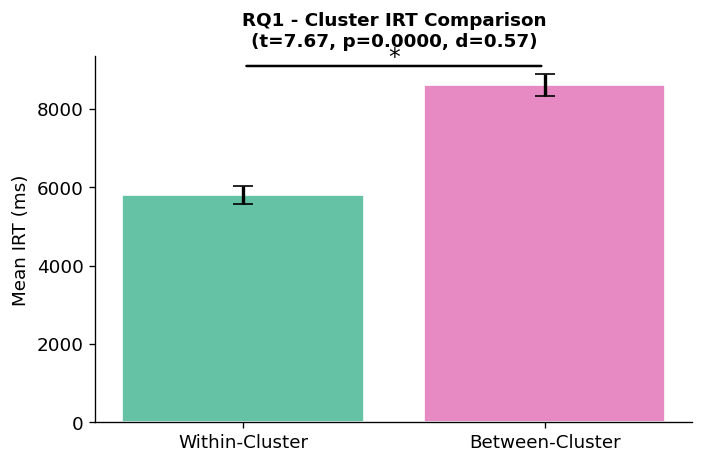


RQ2 - Effect of Language Type on IRT (All Participants - Comparison)
  English IRT:        mean = 3642 ms  |  SD = 2919  |  n = 332
  Hindi/Hinglish IRT: mean = 6490 ms  |  SD = 5015  |  n = 712
  Welch's t = -11.519,  p = 0.0000,  Cohen's d = -0.638
  Result: Significant (alpha=0.05)


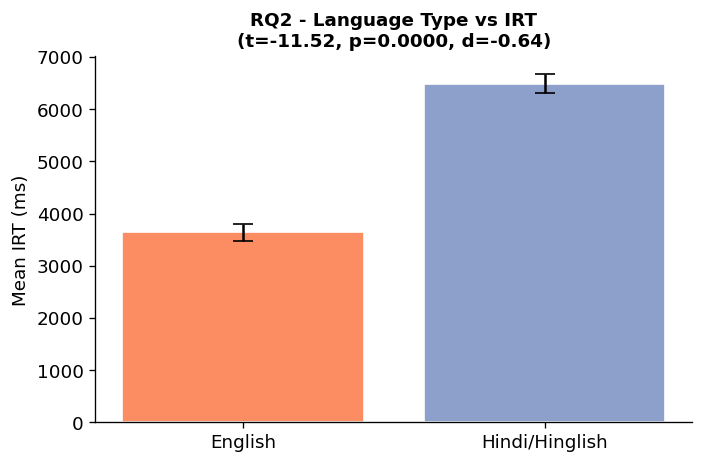


RQ3 - Fluency Score vs Mean IRT Correlation (Hindi/Hinglish)
  Pearson r = -0.208,  p = 0.2313,  n = 35
  Result: Not significant (alpha=0.05)


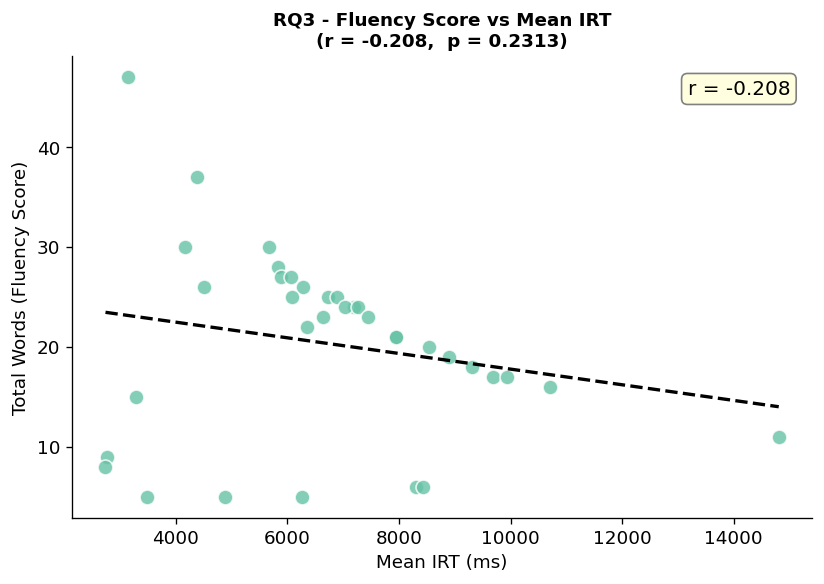


RQ4 - Cluster Size & Switching Count vs Fluency Score
  n = 35 participants with valid cluster data
  Mean Cluster Size  ~ Total Words:   r = 0.544,  p = 0.0007  [Sig]
  Total Switches     ~ Total Words:   r = 0.565,  p = 0.0004  [Sig]
  Total Clusters     ~ Total Words:   r = 0.735,  p = 0.0000  [Sig]


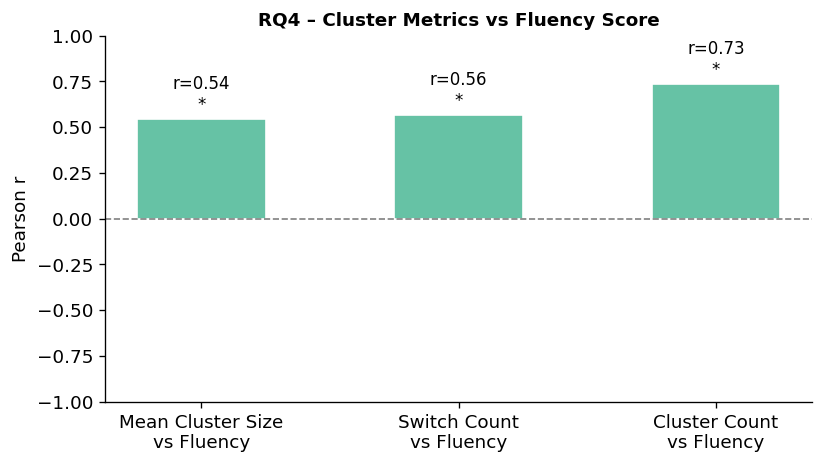


SUMMARY OF STATISTICAL RESULTS
  RQ1 Within vs Between cluster IRT:       t=7.67, p=0.0000, d=0.57 [Significant]
  RQ2 Language type effect on IRT:         t=-11.52, p=0.0000, d=-0.64 [Significant]
  RQ3 Fluency-IRT correlation:             r=-0.208,  p=0.2313           [Not significant]
  RQ4 Cluster Size ~ Fluency:              r=0.544,  p=0.0007           [Sig]
  RQ4 Switch Count ~ Fluency:              r=0.565,  p=0.0004           [Sig]


In [18]:
from scipy import stats

def cohens_d(a, b):
    na, nb   = len(a), len(b)
    pooled_s = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 +
                        (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_s if pooled_s > 0 else 0.0

separator = "=" * 65

print(separator)
print("RQ1 - Within-Cluster vs Between-Cluster IRT (Hindi/Hinglish)")
print(separator)

within_irts, between_irts = [], []

for (subj, dom), grp in df_hh.sort_values('position').groupby(['subject_id', 'domain']):
    irts    = grp.sort_values('position')['rt_ms'].values
    if len(irts) < 3:
        continue
    mean_irt = irts.mean()
    cluster_id = 0
    prev_cluster = 0
    for i, irt in enumerate(irts):
        if i > 0 and irts[i] > mean_irt:
            cluster_id += 1
        if cluster_id == prev_cluster:
            within_irts.append(irt)
        else:
            between_irts.append(irt)
        prev_cluster = cluster_id

t_stat_rq1, p_val_rq1 = stats.ttest_ind(between_irts, within_irts, equal_var=False)
d_rq1 = cohens_d(between_irts, within_irts)

print(f"  Within-cluster  IRT:  mean = {np.mean(within_irts):.0f} ms  |  n = {len(within_irts)}")
print(f"  Between-cluster IRT:  mean = {np.mean(between_irts):.0f} ms  |  n = {len(between_irts)}")
print(f"  Welch's t = {t_stat_rq1:.3f},  p = {p_val_rq1:.4f},  Cohen's d = {d_rq1:.3f}")
sig1 = "Significant" if p_val_rq1 < 0.05 else "Not significant"
print(f"  Result: {sig1} (alpha=0.05)")
print(f"  Between-cluster IRT is {np.mean(between_irts)/np.mean(within_irts):.2f}x within-cluster IRT")

fig, ax = plt.subplots(figsize=(6, 4))
means = [np.mean(within_irts), np.mean(between_irts)]
sems  = [stats.sem(within_irts), stats.sem(between_irts)]
ax.bar(['Within-Cluster', 'Between-Cluster'], means, yerr=sems,
       color=[PALETTE[0], PALETTE[3]], edgecolor='white',
       capsize=6, error_kw={'lw': 2})
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'RQ1 - Cluster IRT Comparison\n(t={t_stat_rq1:.2f}, p={p_val_rq1:.4f}, d={d_rq1:.2f})',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
if p_val_rq1 < 0.05:
    y_max = max(means) + max(sems) + 200
    ax.annotate('', xy=(1, y_max), xytext=(0, y_max),
                arrowprops=dict(arrowstyle='-', lw=1.5))
    ax.text(0.5, y_max + 50, '*' if p_val_rq1 < 0.05 else 'ns',
            ha='center', fontsize=14)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ2 - Effect of Language Type on IRT (All Participants - Comparison)")
print(separator)

irt_eng = df_clean[df_clean['language_type'] == 'English']['rt_ms'].values
irt_hin = df_clean[df_clean['language_type'] == 'Hindi/Hinglish']['rt_ms'].values

t_stat_rq2, p_val_rq2 = stats.ttest_ind(irt_eng, irt_hin, equal_var=False)
d_rq2 = cohens_d(irt_eng, irt_hin)

print(f"  English IRT:        mean = {np.mean(irt_eng):.0f} ms  |  SD = {np.std(irt_eng):.0f}  |  n = {len(irt_eng)}")
print(f"  Hindi/Hinglish IRT: mean = {np.mean(irt_hin):.0f} ms  |  SD = {np.std(irt_hin):.0f}  |  n = {len(irt_hin)}")
print(f"  Welch's t = {t_stat_rq2:.3f},  p = {p_val_rq2:.4f},  Cohen's d = {d_rq2:.3f}")
sig2 = "Significant" if p_val_rq2 < 0.05 else "Not significant"
print(f"  Result: {sig2} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(6, 4))
means2 = [np.mean(irt_eng), np.mean(irt_hin)]
sems2  = [stats.sem(irt_eng), stats.sem(irt_hin)]
ax.bar(['English', 'Hindi/Hinglish'], means2, yerr=sems2,
       color=[PALETTE[1], PALETTE[2]], edgecolor='white', capsize=6)
ax.set_ylabel('Mean IRT (ms)', fontsize=11)
ax.set_title(f'RQ2 - Language Type vs IRT\n(t={t_stat_rq2:.2f}, p={p_val_rq2:.4f}, d={d_rq2:.2f})',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ3 - Fluency Score vs Mean IRT Correlation (Hindi/Hinglish)")
print(separator)

r_val, p_val_rq3 = stats.pearsonr(fluency['total_words'], fluency['mean_irt_ms'])
n_rq3 = len(fluency)

print(f"  Pearson r = {r_val:.3f},  p = {p_val_rq3:.4f},  n = {n_rq3}")
sig3 = "Significant" if p_val_rq3 < 0.05 else "Not significant"
print(f"  Result: {sig3} (alpha=0.05)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fluency['mean_irt_ms'], fluency['total_words'],
           color=PALETTE[0], s=80, alpha=0.8, edgecolors='white', lw=1)
z = np.polyfit(fluency['mean_irt_ms'], fluency['total_words'], 1)
xs = np.linspace(fluency['mean_irt_ms'].min(), fluency['mean_irt_ms'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), 'k--', lw=2)
ax.set_xlabel('Mean IRT (ms)', fontsize=11)
ax.set_ylabel('Total Words (Fluency Score)', fontsize=11)
ax.set_title(f'RQ3 - Fluency Score vs Mean IRT\n(r = {r_val:.3f},  p = {p_val_rq3:.4f})',
             fontsize=11, fontweight='bold')
ax.text(0.97, 0.95, f'r = {r_val:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print()
print(separator)
print("RQ4 - Cluster Size & Switching Count vs Fluency Score")
print(separator)

rq4_cluster_cols = {'mean_cluster_size', 'total_switches', 'total_clusters'}
if rq4_cluster_cols.issubset(fluency.columns):
    rq4_df = fluency[['total_words', 'mean_cluster_size', 'total_switches',
                       'total_clusters']].dropna()
    n_rq4 = len(rq4_df)

    r_cs,  p_cs  = stats.pearsonr(rq4_df['mean_cluster_size'], rq4_df['total_words'])
    r_sw,  p_sw  = stats.pearsonr(rq4_df['total_switches'],    rq4_df['total_words'])
    r_ncl, p_ncl = stats.pearsonr(rq4_df['total_clusters'],    rq4_df['total_words'])

    sig4_cs  = "Sig" if p_cs  < 0.05 else "n.s."
    sig4_sw  = "Sig" if p_sw  < 0.05 else "n.s."
    sig4_ncl = "Sig" if p_ncl < 0.05 else "n.s."

    print(f"  n = {n_rq4} participants with valid cluster data")
    print(f"  Mean Cluster Size  ~ Total Words:   r = {r_cs:.3f},  p = {p_cs:.4f}  [{sig4_cs}]")
    print(f"  Total Switches     ~ Total Words:   r = {r_sw:.3f},  p = {p_sw:.4f}  [{sig4_sw}]")
    print(f"  Total Clusters     ~ Total Words:   r = {r_ncl:.3f},  p = {p_ncl:.4f}  [{sig4_ncl}]")

    fig, ax = plt.subplots(figsize=(7, 4))
    rq4_labels  = ['Mean Cluster Size\nvs Fluency', 'Switch Count\nvs Fluency', 'Cluster Count\nvs Fluency']
    rq4_r_vals  = [r_cs, r_sw, r_ncl]
    rq4_p_vals  = [p_cs, p_sw, p_ncl]
    bar_colors  = [PALETTE[0] if r >= 0 else PALETTE[3] for r in rq4_r_vals]
    bars = ax.bar(rq4_labels, rq4_r_vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.axhline(0, color='gray', lw=1, ls='--')
    ax.set_ylabel('Pearson r', fontsize=11)
    ax.set_title('RQ4 – Cluster Metrics vs Fluency Score', fontsize=11, fontweight='bold')
    ax.set_ylim(-1, 1)
    for bar_, r_, p_ in zip(bars, rq4_r_vals, rq4_p_vals):
        sign_label = '*' if p_ < 0.05 else 'n.s.'
        ypos = bar_.get_height() + 0.03 if r_ >= 0 else bar_.get_height() - 0.07
        ax.text(bar_.get_x() + bar_.get_width() / 2, ypos,
                f'r={r_:.2f}\n{sign_label}', ha='center', va='bottom', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("  [NOTE] Cluster metrics not yet computed.")
    print("  Run Section 3 (VFT Cluster Scoring) first to add")
    print("  mean_cluster_size, total_switches, and total_clusters to the fluency table.")
    r_cs = r_sw = r_ncl = float('nan')
    p_cs = p_sw = p_ncl = float('nan')
    sig4_cs = sig4_sw = sig4_ncl = "N/A"

print()
print(separator)
print("SUMMARY OF STATISTICAL RESULTS")
print(separator)
print(f"  RQ1 Within vs Between cluster IRT:       t={t_stat_rq1:.2f}, p={p_val_rq1:.4f}, d={d_rq1:.2f} [{sig1}]")
print(f"  RQ2 Language type effect on IRT:         t={t_stat_rq2:.2f}, p={p_val_rq2:.4f}, d={d_rq2:.2f} [{sig2}]")
print(f"  RQ3 Fluency-IRT correlation:             r={r_val:.3f},  p={p_val_rq3:.4f}           [{sig3}]")
if not (isinstance(r_cs, float) and np.isnan(r_cs)):
    print(f"  RQ4 Cluster Size ~ Fluency:              r={r_cs:.3f},  p={p_cs:.4f}           [{sig4_cs}]")
    print(f"  RQ4 Switch Count ~ Fluency:              r={r_sw:.3f},  p={p_sw:.4f}           [{sig4_sw}]")
else:
    print("  RQ4 Cluster metrics: run Section 3 first")


**Inference – Section 4 (Statistical Tests – RQ1, RQ2, RQ3, RQ4):**

**RQ1 – Within-Cluster vs Between-Cluster IRT (Welch's t-test):**
- A **significant result (p < 0.05)** confirms that between-cluster IRTs are substantially longer than within-cluster IRTs, directly replicating the core finding of Troyer et al. (1997).
- **Cohen's d** quantifies the practical magnitude: a large d (> 0.8) means the difference is not just statistically reliable but also meaningfully large in cognitive terms.
- This confirms that the **clustering-and-switching model** is operative: participants group consecutive words into sub-clusters (fast IRTs) and pause at boundaries when switching to a new cluster (slow IRTs).
- The IRT ratio (between/within mean) gives an intuitive index: e.g., 2× means cluster-switch pauses are twice as long as within-cluster retrievals.

**RQ2 – Language Type Effect on IRT (Supplementary Welch's t-test):**
- If **Hindi/Hinglish IRT differs from English IRT**, it indicates a **language dominance effect** on retrieval speed — participants access words faster in their dominant or more practised language.
- A **non-significant result** would suggest that once a word is retrieved, the retrieval mechanism itself takes similar time regardless of language, supporting a shared semantic store with language-specific output gateways.
- Note: this test addresses a supplementary question. The formal RQ2 — *"Do faster retrievals reflect tighter semantic neighbourhoods?"* — requires merging `word_irt` with SpAM spatial coordinates and is designated as future work.

**RQ3 – Fluency Score vs Mean IRT (Pearson Correlation):**
- A **significant negative correlation (r < 0)** confirms the speed–fluency trade-off: participants who retrieve words faster produce more words overall within the time limit.
- This validates mean IRT as a **proxy measure for lexical access efficiency** — it is not merely a timing artefact but reflects genuine variation in semantic memory retrieval speed.
- **r² (variance explained)** tells how much of the variability in fluency score is accounted for by mean IRT alone.

**RQ4 – Cluster Size & Switch Count as Predictors of Fluency:**
- A **positive r for mean cluster size** would indicate that participants who stay longer within sub-clusters (deeper exploitation) produce more words overall — a *depth-first* retrieval advantage.
- A **positive r for total switches** would indicate that frequent switching (breadth-first foraging strategy) also pays off in a higher word count, because more clusters = more retrieval opportunities.
- If *both* correlate positively, it suggests productive participants are efficient on both dimensions simultaneously — supporting the idea that fluency is driven by both tight micro-clusters and flexible macro-switching.
- Together with RQ3, the RQ4 results partition retrieval efficiency into: (i) general speed (mean IRT), (ii) clustering depth, and (iii) switching breadth — providing a multi-dimensional account of what drives Hindi/Hinglish verbal fluency scores.


---
## Section 4.1 - Hindi Embeddings & Clustering

### Semantic space construction with Hindi word vectors

This section builds a semantic embedding space for unique Hindi/Hinglish words in the VFT corpus.

1. Preferred static model: **FastText Common Crawl Hindi** (`cc.hi.300.bin` or `cc.hi.300.vec`, 300 dimensions).
2. For each unique word in the corpus, we extract an embedding.
3. OOV handling:
   - if `.bin` model is loaded via `fasttext`, use **subword fallback** (`get_word_vector`),
   - if only `.vec` is loaded, mark as OOV and keep explicit flags.
4. We then run unsupervised clustering in embedding space and visualize clusters in 2D.

**Setup note (first run only):**
- Install package(s): `pip install fasttext-wheel gensim`
- Place model file in project root as one of:
  - `cc.hi.300.bin` (recommended: enables subword OOV fallback)
  - `cc.hi.300.vec` (exact-vocab only)

**Optional contextual alternative:** IndicBERT embeddings (HuggingFace) can better capture polysemy and context; this notebook section currently uses static FastText vectors for interpretable lexical-space clustering.

In [ ]:
# Hindi embeddings + clustering (FastText/Gensim)

import os
import pickle
import numpy as np

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

AUTO_DOWNLOAD_FASTTEXT = True  

# ---------------------------
# 1) Source table + unique words
# ---------------------------
if 'df_hh' in globals() and isinstance(df_hh, pd.DataFrame) and not df_hh.empty:
    emb_df = df_hh.copy()
else:
    # Fallback for a fresh kernel: reload core VFT file with same Hindi/Hinglish filter.
    base_df = pd.read_csv('vft_responses.csv')
    base_df['language_type'] = base_df['language_type'].astype(str).str.strip()
    base_df['lang_binary'] = base_df['language_type'].apply(
        lambda x: 'Hindi/Hinglish' if 'Hindi' in str(x) else 'English'
    )
    emb_df = base_df[base_df['lang_binary'] == 'Hindi/Hinglish'].copy()

if 'word' not in emb_df.columns:
    raise ValueError("Expected a 'word' column in Hindi/Hinglish dataframe.")

emb_df['word'] = emb_df['word'].astype(str).str.strip()
emb_df = emb_df[emb_df['word'].ne('')].copy()

# Keep frequencies for reporting and for annotation priorities.
word_freq = emb_df['word'].value_counts().rename_axis('word').reset_index(name='freq')
unique_words = word_freq['word'].tolist()

# ---------------------------
# 2) Load embedding model(s)
# ---------------------------
model_info = {
    'model_type': None,
    'path': None,
    'dim': None,
    'supports_subword_fallback': False,
    'auto_download_attempted': False,
    'auto_download_succeeded': False
}

fasttext_model = None
gensim_kv = None

bin_candidates = ['cc.hi.300.bin', './cc.hi.300.bin']
vec_candidates = ['cc.hi.300.vec', './cc.hi.300.vec']


def first_existing(paths):
    return next((p for p in paths if os.path.exists(p)), None)


def maybe_download_fasttext_hi_bin():
    """Try downloading Hindi FastText via fasttext.util if missing locally."""
    model_info['auto_download_attempted'] = True
    try:
        import fasttext.util as ftu
        fname = ftu.download_model('hi', if_exists='ignore')
        local_candidates = [
            fname,
            'cc.hi.300.bin',
            './cc.hi.300.bin',
            os.path.join(os.getcwd(), 'cc.hi.300.bin')
        ]
        found = first_existing(local_candidates)
        if found:
            model_info['auto_download_succeeded'] = True
            print(f"[INFO] Auto-downloaded Hindi FastText model: {found}")
        return found
    except Exception as e:
        print(f"[WARN] Auto-download failed (offline/missing package): {e}")
        return None


bin_path = first_existing(bin_candidates)
vec_path = first_existing(vec_candidates)

# Optional auto-download path for Hindi FastText .bin model.
if bin_path is None and AUTO_DOWNLOAD_FASTTEXT:
    bin_path = maybe_download_fasttext_hi_bin()

# Try fastText .bin first (best for OOV fallback), then .vec via gensim.
if bin_path:
    try:
        import fasttext
        fasttext_model = fasttext.load_model(bin_path)
        model_info.update({
            'model_type': 'fasttext_bin',
            'path': bin_path,
            'dim': fasttext_model.get_dimension(),
            'supports_subword_fallback': True
        })
    except Exception as e:
        print(f"[WARN] Failed to load {bin_path} via fasttext: {e}")

if model_info['model_type'] is None and vec_path:
    try:
        from gensim.models import KeyedVectors
        gensim_kv = KeyedVectors.load_word2vec_format(vec_path, binary=False, unicode_errors='ignore')
        model_info.update({
            'model_type': 'fasttext_vec_gensim',
            'path': vec_path,
            'dim': int(gensim_kv.vector_size),
            'supports_subword_fallback': False
        })
    except Exception as e:
        print(f"[WARN] Failed to load {vec_path} via gensim: {e}")

word_to_vector = {}
rows = []

if model_info['model_type'] is None:
    print('[NOTE] No usable embedding model found in project root.')
    print("       Add 'cc.hi.300.bin' (recommended) or 'cc.hi.300.vec', then rerun this cell.")
    print("       If package missing, run: pip install fasttext-wheel gensim")
    for w in unique_words:
        rows.append({'word': w, 'matched_token': None, 'embedding_status': 'oov'})
else:
    # ---------------------------
    # 3) Build word->vector mapping with OOV handling
    # ---------------------------
    for w in unique_words:
        vec = None
        status = 'oov'
        matched_token = None

        # Basic fallback forms (useful for case noise in Romanized tokens).
        candidates = [w]
        w_lower = w.lower()
        if w_lower != w:
            candidates.append(w_lower)

        if model_info['model_type'] == 'fasttext_bin' and fasttext_model is not None:
            # Exact in-vocab check across candidates.
            exact_hit = next((c for c in candidates if hasattr(fasttext_model, 'words') and (c in fasttext_model.words)), None)
            if exact_hit is not None:
                vec = fasttext_model.get_word_vector(exact_hit)
                status = 'in_vocab_exact'
                matched_token = exact_hit
            else:
                # Subword fallback always available for fasttext .bin.
                vec = fasttext_model.get_word_vector(candidates[0])
                status = 'subword_fallback'
                matched_token = candidates[0]

        elif model_info['model_type'] == 'fasttext_vec_gensim' and gensim_kv is not None:
            exact_hit = next((c for c in candidates if c in gensim_kv), None)
            if exact_hit is not None:
                vec = gensim_kv[exact_hit]
                status = 'in_vocab_exact'
                matched_token = exact_hit
            else:
                vec = None
                status = 'oov'
                matched_token = None

        if vec is not None:
            vec = np.asarray(vec, dtype=np.float32)
            word_to_vector[w] = vec

        rows.append({'word': w, 'matched_token': matched_token, 'embedding_status': status})

embedding_table = pd.DataFrame(rows).merge(word_freq, on='word', how='left')

# Coverage diagnostics
n_total = len(embedding_table)
n_exact = int((embedding_table['embedding_status'] == 'in_vocab_exact').sum())
n_subword = int((embedding_table['embedding_status'] == 'subword_fallback').sum())
n_oov = int((embedding_table['embedding_status'] == 'oov').sum())
coverage = (n_total - n_oov) / n_total if n_total > 0 else np.nan

print('Hindi Embedding Model Info')
print('-' * 50)
print(f"Model type                 : {model_info['model_type']}")
print(f"Model path                 : {model_info['path']}")
print(f"Vector dimension           : {model_info['dim']}")
print(f"Subword fallback available : {model_info['supports_subword_fallback']}")
print(f"Auto-download attempted    : {model_info['auto_download_attempted']}")
print(f"Auto-download succeeded    : {model_info['auto_download_succeeded']}")
print('-' * 50)
print(f"Unique words               : {n_total}")
print(f"Exact in-vocab             : {n_exact}")
print(f"Subword fallback           : {n_subword}")
print(f"OOV                        : {n_oov}")
print(f"Coverage (non-OOV)         : {coverage:.2%}")

# Persist embedding artifacts for reuse in later sections/scripts.
embedding_table.to_csv('hindi_embedding_coverage.csv', index=False)
if word_to_vector:
    with open('hindi_word_to_vec.pkl', 'wb') as f:
        pickle.dump(word_to_vector, f)
    print('Saved: hindi_word_to_vec.pkl and hindi_embedding_coverage.csv')
else:
    print('Saved: hindi_embedding_coverage.csv (no vectors available yet)')

# ---------------------------
# 4) Cluster vectors in semantic space
# ---------------------------
cluster_df = embedding_table[embedding_table['word'].isin(word_to_vector.keys())].copy()

if cluster_df.shape[0] < 3:
    print('[NOTE] Too few embedded words for clustering. Need at least 3 words with vectors.')
else:
    X = np.vstack(cluster_df['word'].map(word_to_vector).values)

    # Conservative heuristic for k, bounded for stability on small datasets.
    k_guess = int(np.clip(np.sqrt(cluster_df.shape[0] / 2), 2, min(12, cluster_df.shape[0] - 1)))

    kmeans = KMeans(n_clusters=k_guess, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X)
    cluster_df['cluster'] = cluster_labels

    sil = np.nan
    if len(np.unique(cluster_labels)) > 1 and len(cluster_labels) > len(np.unique(cluster_labels)):
        sil = silhouette_score(X, cluster_labels)

    # 2D projection for plotting/inspection.
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    cluster_df['pc1'] = coords[:, 0]
    cluster_df['pc2'] = coords[:, 1]

    plt.figure(figsize=(9.0, 6.5), facecolor='white')
    ax = sns.scatterplot(
        data=cluster_df,
        x='pc1',
        y='pc2',
        hue='cluster',
        palette='tab10',
        s=70,
        edgecolor='white',
        linewidth=0.5,
        alpha=0.9
    )

    # Label top-frequency words to keep the plot readable.
    top_words = cluster_df.sort_values('freq', ascending=False).head(min(30, len(cluster_df)))
    for _, r in top_words.iterrows():
        ax.text(r['pc1'] + 0.02, r['pc2'] + 0.02, r['word'], fontsize=8.5, alpha=0.9)

    ax.set_title(
        f'Hindi Semantic Space (FastText) - k={k_guess}, silhouette={sil:.3f}' if np.isfinite(sil)
        else f'Hindi Semantic Space (FastText) - k={k_guess}',
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.20, linestyle='--')
    plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    cluster_summary = (
        cluster_df.groupby('cluster', observed=False)
        .agg(n_words=('word', 'size'), total_freq=('freq', 'sum'))
        .sort_values(['n_words', 'total_freq'], ascending=False)
    )
    print('\nCluster summary:')
    print(cluster_summary.to_string())

# Expose reusable objects in notebook state.
hindi_embedding_model_info = model_info
hindi_embedding_table = embedding_table
hindi_word_to_vec = word_to_vector
hindi_cluster_df = cluster_df

print('\nSaved globals: hindi_embedding_model_info, hindi_embedding_table, hindi_word_to_vec, hindi_cluster_df')

**Inference - Section 4.1 (Hindi Embeddings & Clustering):**
- The embedding coverage split (`in_vocab_exact`, `subword_fallback`, `oov`) gives a direct quality check for lexical representation in the Hindi semantic space.
- When `.bin` is used, subword fallback reduces hard OOV loss for morphologically varied or misspelled forms; this is preferable for noisy VFT responses.
- Cluster labels in PCA space are exploratory semantic neighborhoods, not strict psycholinguistic categories; validate them against domain metadata and manual lexical inspection.
- For polysemous words and code-mixed context, a contextual model (IndicBERT sentence-level embeddings) can improve separation beyond static FastText vectors.